In [29]:
"""
quantized_models_comparison.py
------------------------------
Comparison of six SGD estimators on random Fourier features.

  fp             full-precision features
  quant_naive    stochastic quantization at every step, no correction
  quant_scalar   same, with scalar correction D_sca (Ch. 3)
  frozen_naive   features quantized ONCE and stored, no correction
  frozen_scalar  same, with scalar correction
  det            deterministic (sign) quantization, evaluated on its own
                 features: it estimates the mixture kernel, not k

Evaluation. By default every model is tested on FP features, since this is what
Ch. 3 bounds: the excess risk of f_t = <phi_M(.), w_t>. With
frozen_test="quantized" the frozen models are tested on their own stored
features; the gap between the two is the test-side quantization term,
<= (2/M)||w||^2. The det model is the exception: its w lives in a different
feature space, so it must be evaluated natively.

No full-precision feature matrix is materialized during training: fp, quant_*
and det recompute the mini-batch block. Only frozen_* stores features (uint8 codes).

Usage
-----
    from quantized_models_comparison import CONFIGS, run_comparison, plot_accuracy, plot_memory

    X, y, sigma = load_dataset("casp", normalize=True, median_heuristic=True,
                               n_samples=10000, random_state=42)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
    res = run_comparison(Xtr, ytr, Xte, yte, sigma, **CONFIGS["casp_gau_1pass"])
"""
import os, gc, json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.kernel_ridge import KernelRidge

from utils.dataset_selection import load_dataset
from utils.sampling_and_features import SamplingFeatureClass
from utils.sgd_predictor import SGDPredictor


MODELS = ("fp", "quant_naive", "quant_scalar", "frozen_naive", "frozen_scalar", "det")
MODELS_TO_PLOT = ("fp", "quant_naive", "frozen_naive", "det")
COLORS = {"fp": "#1f77b4", "quant_naive": "#ff7f0e", "quant_scalar": "#d62728",
          "frozen_naive": "#9467bd", "frozen_scalar": "#2ca02c", "det": "red"}
LABELS = {"fp": "FP", "quant_naive": "quant naive", "quant_scalar": "quant debias (1/M)",
          "frozen_naive": "frozen naive", "frozen_scalar": "frozen debias (1/M)",
          "det": "det (sign)"}
STORED = {"fp": 64, "frozen_naive": None, "frozen_scalar": None, "det": 1}


# ---------------------------------------------------------------------------
# 1. Features and quantization
# ---------------------------------------------------------------------------

# Returns the (k, M) feature block. "stoch" has scale sqrt(2/M), "det" sqrt(1/M).
def features(sampler, Xb, kind, bits):
    if kind == "fp":
        return sampler.feature_map_approx(Xb, mode=1)
    if kind == "det":
        return sampler.sgn_feature_map(Xb, mode=1)
    return sampler.s_bit_feature_map(Xb, s=bits, mode=1, random_quantization=True)


# Returns (n, M) uint8 codes in [0, 2^bits - 1]; the dither is drawn once.
def quantize_codes(sampler, X, bits, rng, chunk=4096):
    L = 2 ** bits
    codes = np.empty((X.shape[0], sampler.M), dtype=np.uint8)
    for a in range(0, X.shape[0], chunk):
        m = (np.cos(X[a:a + chunk] @ sampler.w.T + sampler.u) + 1.0) / 2.0 * (L - 1)
        fl = np.floor(m)
        codes[a:a + chunk] = (fl + (rng.random(m.shape) < (m - fl))).astype(np.uint8)
    return codes


# Maps codes back to features, with the same scale as features(..., "stoch", bits).
def codes_to_features(codes, M, bits):
    return np.sqrt(2.0 / M) * (-1.0 + codes.astype(np.float64) * (2.0 / (2 ** bits - 1)))


# Deterministic surrogate of Dbar = (2/M) Delta^2 E[p(1-p)]:
#   bits = 1: p = (1+cos)/2 arcsine-distributed, E[p(1-p)] = 1/8  ->  1/M
#   bits > 1: p uniform on the cell,            E[p(1-p)] = 1/6  ->  (4/3) / (M (2^b-1)^2)
def Dbar_scalar(M, bits):
    return 1.0 / M if bits == 1 else (4.0 / 3.0) / (M * (2 ** bits - 1) ** 2)


# Exact Dbar (M,) on the training set; used only in the diagnostics.
def estimate_Dbar(sampler, X, bits, chunk=2048):
    L = 2 ** bits
    acc = np.zeros(sampler.M)
    for a in range(0, X.shape[0], chunk):
        p = ((np.cos(X[a:a + chunk] @ sampler.w.T + sampler.u) + 1.0) / 2.0 * (L - 1)) % 1.0
        acc += (p * (1.0 - p)).sum(axis=0)
    return (2.0 / sampler.M) * (2.0 / (L - 1)) ** 2 * (acc / X.shape[0])


# ---------------------------------------------------------------------------
# 2. Training and evaluation
# ---------------------------------------------------------------------------

# Yields (t, idx). single_pass=True: permutation without replacement, each sample
# is used once, so streaming and frozen estimators coincide in law.
def _batches(n, cfg, rng):
    if cfg.get("single_pass", False):
        perm = rng.permutation(n)
        for t in range(min(cfg["T"], n // cfg["batch"])):
            yield t, perm[t * cfg["batch"]:(t + 1) * cfg["batch"]]
    else:
        for t in range(cfg["T"]):
            yield t, rng.integers(0, n, cfg["batch"])


# Features are recomputed at every step, never stored.
def train_online(sampler, X, y, cfg, rng, kind, D=None):
    m = SGDPredictor(x_dim=sampler.M, lr=cfg["lr"], decay_rate=cfg["decay"])
    for t, idx in _batches(X.shape[0], cfg, rng):
        m.partial_fit(features(sampler, X[idx], kind, cfg["bits"]), y[idx], t, D=D)
    return m


# Only the current mini-batch is converted back to floats.
def train_frozen(codes, y, M, cfg, rng, D=None):
    m = SGDPredictor(x_dim=M, lr=cfg["lr"], decay_rate=cfg["decay"])
    for t, idx in _batches(codes.shape[0], cfg, rng):
        m.partial_fit(codes_to_features(codes[idx], M, cfg["bits"]), y[idx], t, D=D)
    return m


# Test MSE computed in chunks (no full-precision (n_te, M) matrix).
def mse_online(model, sampler, X, y, kind, bits, chunk=4096):
    s = 0.0
    for a in range(0, X.shape[0], chunk):
        s += float(((model.predict(features(sampler, X[a:a + chunk], kind, bits))
                     - y[a:a + chunk]) ** 2).sum())
    return s / X.shape[0]


# Test MSE on stored quantized test features.
def mse_codes(model, codes, y, M, bits, chunk=4096):
    s = 0.0
    for a in range(0, codes.shape[0], chunk):
        s += float(((model.predict(codes_to_features(codes[a:a + chunk], M, bits))
                     - y[a:a + chunk]) ** 2).sum())
    return s / codes.shape[0]


# ---------------------------------------------------------------------------
# 3. Diagnostics
# ---------------------------------------------------------------------------

# sum_t mu_t = 1/lambda
def sum_lr(cfg, n):
    T = min(cfg["T"], n // cfg["batch"]) if cfg.get("single_pass", False) else cfg["T"]
    return float((cfg["lr"] / (1.0 + cfg["decay"] * np.arange(T))).sum())


# Spectrum of the mean operators. With the exact correction the mean operator is
# C (PSD, never expansive); with the scalar one it is C + diag(Dbar) - Dsca I,
# indefinite, and its lambda_min governs stability.
def diagnostics(sampler, X, Dsca, cfg):
    n, M = X.shape[0], sampler.M
    Z = sampler.feature_map_approx(X, mode=1)
    C = Z.T @ Z / n
    Dbar = estimate_Dbar(sampler, X, cfg["bits"])
    lam = float(np.linalg.eigvalsh(C + np.diag(Dbar - Dsca))[0])
    S = sum_lr(cfg, n)
    return {"sum_lr": S, "lam_min_C": float(np.linalg.eigvalsh(C)[0]),
            "lam_min_scalar": lam, "Dbar_mean": float(Dbar.mean()), "D_scalar": float(Dsca),
            "amp_scalar": float(np.exp(min(2.0 * S * max(0.0, -lam), 700.0)))}


# Stored feature bits. Online models store nothing: their cost is recomputation,
# not memory. omega (M*d*64 bits) is common to all models and not counted.
def stored_bits(n_tr, n_te, M, bits, model):
    if model == "fp":
        return (n_tr + n_te) * M * 64
    if model in ("frozen_naive", "frozen_scalar"):
        return (n_tr + n_te) * M * bits
    if model == "det":
        return (n_tr + n_te) * M * 1
    return 0


# ---------------------------------------------------------------------------
# 4. Sweep
# ---------------------------------------------------------------------------

# Returns a JSON-serializable dict: mean/std over n_reps draws of (omega, u, dither).
def run_comparison(Xtr, ytr, Xte, yte, sigma, M_values, cfg, n_reps=3, seed=42,
                   kernel="gaussian", nu=2.5, rho=None, diag_max_M=1200,
                   frozen_test="fp", dataset="dataset", save_path=None):
    n, d = Xtr.shape
    n_te = Xte.shape[0]
    rho = sigma if rho is None else rho
    mean = {k: np.full(len(M_values), np.nan) for k in MODELS}
    std = {k: np.full(len(M_values), np.nan) for k in MODELS}
    diags = {}

    for i, M in enumerate(M_values):
        M = int(M)
        Dsca = Dbar_scalar(M, cfg["bits"])
        acc = {k: [] for k in MODELS}

        for r in range(n_reps):
            rs = seed + 1000 * r + i
            np.random.seed(rs)
            sampler = SamplingFeatureClass(M_RFF_dim=M, d_data_dim=d, sigma_ker=rho,
                                           choice=kernel, nu=nu, ro=rho)
            codes_tr = quantize_codes(sampler, Xtr, cfg["bits"], np.random.default_rng(rs + 1))
            codes_te = quantize_codes(sampler, Xte, cfg["bits"], np.random.default_rng(rs + 2))

            if r == 0 and M <= diag_max_M:
                diags[M] = diagnostics(sampler, Xtr, Dsca, cfg)

            for name, kind, D in [("fp", "fp", None), ("det", "det", None),
                                  ("quant_naive", "stoch", None),
                                  ("quant_scalar", "stoch", Dsca)]:
                np.random.seed(rs + 7)
                m = train_online(sampler, Xtr, ytr, cfg, np.random.default_rng(rs), kind, D)
                acc[name].append(mse_online(m, sampler, Xte, yte,
                                            kind if kind != "stoch" else "fp", cfg["bits"]))

            for name, D in [("frozen_naive", None), ("frozen_scalar", Dsca)]:
                m = train_frozen(codes_tr, ytr, M, cfg, np.random.default_rng(rs), D)
                acc[name].append(mse_codes(m, codes_te, yte, M, cfg["bits"])
                                 if frozen_test == "quantized" else
                                 mse_online(m, sampler, Xte, yte, "fp", cfg["bits"]))

            del sampler, codes_tr, codes_te
            gc.collect()

        for k in MODELS_TO_PLOT:
            v = np.asarray(acc[k], float)
            v[~np.isfinite(v)] = np.nan
            if not np.isnan(v).all():
                mean[k][i], std[k][i] = float(np.nanmean(v)), float(np.nanstd(v))
        print(f"  M={M:>6}  " + "  ".join(f"{k}={mean[k][i]:.4f}" for k in MODELS))

    results = {
        "dataset": dataset, "kernel": kernel, "rho": float(rho),
        "nu": float(nu) if kernel == "matern" else None,
        "M_values": [int(m) for m in M_values], "d": int(d),
        "n_train": int(n), "n_test": int(n_te), "cfg": cfg, "n_reps": int(n_reps),
        "frozen_test": frozen_test,
        "sum_lr": sum_lr(cfg, n),
        "mean": {k: [float(v) for v in mean[k]] for k in MODELS},
        "std": {k: [float(v) for v in std[k]] for k in MODELS},
        "diagnostics": {str(k): v for k, v in diags.items()},
        "stored_bits": {k: [stored_bits(n, n_te, int(m), cfg["bits"], k) for m in M_values]
                        for k in MODELS},
    }
    if save_path:
        json.dump(results, open(save_path, "w"), indent=1)
        print(f"[saved] {save_path}")
    return results



In [ ]:

# ---------------------------------------------------------------------------
# 5. Reports and plots
# ---------------------------------------------------------------------------

def print_diagnostics(results):
    print(f"[{results['dataset']}/{results['kernel']}]  1/lambda = {results['sum_lr']:.1f}  "
          f"(the scalar correction is at risk for M <~ 1/lambda)")
    print(f"{'M':>7} {'lam_min(C)':>12} {'Dbar_mean':>11} {'D_scalar':>11} "
          f"{'lam_min(scal)':>14} {'amp':>10}")
    for M, v in sorted(results["diagnostics"].items(), key=lambda kv: int(kv[0])):
        print(f"{int(M):>7} {v['lam_min_C']:>12.2e} {v['Dbar_mean']:>11.2e} "
              f"{v['D_scalar']:>11.2e} {v['lam_min_scalar']:>14.2e} {v['amp_scalar']:>10.2e}")


def _clean(x, y, max_ratio=5.0):
    x, y = np.asarray(x), np.asarray(y, float)
    return x,y


def _curve(ax, x, mu, sd, name):
    xk, yk = _clean(x, mu)
    ax.plot(xk, yk, "o-", color=COLORS[name], label=LABELS[name],
            linewidth=9 if name == "fp" else 1.6, alpha=0.4 if name == "fp" else 1.0)


SKIP_FIRST = {"quant_scalar": 3, "frozen_scalar": 3}
def plot_accuracy(results, models=MODELS, ax=None, save_path=None,
                  skip_first=None, multi_epochs = False, nu = None):
    """Test MSE vs M.

    skip_first: dict model -> number of leading points to omit. Models with the
    scalar correction diverge for M below the stability threshold, and those
    points would squash the axis.
    """
    M = np.asarray(results["M_values"])
    skip_first = SKIP_FIRST if skip_first is None else skip_first
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 6))
    for name in models:
        k = skip_first.get(name, 0)
        _curve(ax, M[k:], np.asarray(results["mean"][name], float)[k:],
               np.asarray(results["std"][name], float)[k:], name)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("M (num. random features)"); ax.set_ylabel("test MSE")
    if multi_epochs: 
        epochs = "multi epochs"
    else: 
        epochs = 'single epoch'
    if nu:
        ax.set_title(f"accuracy vs M  [{results['dataset']}, {results['kernel']} $\\nu =${nu}], {epochs}")
    else:
        ax.set_title(f"accuracy vs M  [{results['dataset']}, {results['kernel']}], {epochs}")
    ax.grid(True, which="both", ls="--", alpha=.5); ax.legend(fontsize=9)
    if save_path:
        ax.figure.savefig(save_path, dpi=120, bbox_inches="tight")
    return ax

# Test MSE vs stored features. Only models that store features are shown:
# quant_* recompute at every step and do not belong on this axis.
def plot_memory(results, ax=None, save_path=None, skip_first = None):
    skip_first = SKIP_FIRST if skip_first is None else skip_first
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 6))
    for name in ("fp", "frozen_naive", "frozen_scalar", "det"):
        k = skip_first.get(name, 0)
        kb = np.asarray(results["stored_bits"][name], float) / 8 / 1024
        _curve(ax, kb[k:], np.asarray(results["mean"][name], float)[k:],
               np.asarray(results["std"][name], float)[k:], name)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("stored features (KB)  [(n_tr+n_te) M b / 8]")
    ax.set_ylabel("test MSE")
    ax.set_title(f"accuracy vs stored memory  [{results['dataset']}, {results['kernel']}]")
    ax.grid(True, which="both", ls="--", alpha=.5); ax.legend(fontsize=9)
    if save_path:
        ax.figure.savefig(save_path, dpi=120, bbox_inches="tight")
    return ax


# ---------------------------------------------------------------------------
# 6. Configurations
# ---------------------------------------------------------------------------
# single-pass: batch=1, T=n_train, each sample used once. The only regime in which
#   streaming and frozen coincide in law. sum_t mu_t = 322 with n_train = 8000.
# multi-epoch: batch=100, T=7000 (~87 passes), sum_t mu_t = 301, hence the same
#   lambda: the only difference from single-pass is the reuse of the dither.

_M = np.logspace(1, 4, 10, dtype=int)
_ONEPASS = dict(T=8000, batch=1, lr=0.02, decay=5e-8, bits=1, single_pass=True)
_EPOCHS = dict(T=7000, batch=100, lr=0.02, decay=5e-8, bits=1)
_EPOCHS_SINGLE_PASS = dict(T=7000, batch=1, lr=0.02, decay=5e-8, bits=1)

CONFIGS_casp = {
    "casp_gau_1pass":   dict(M_values=_M, cfg=_ONEPASS, kernel="gaussian", dataset="casp"),
    "casp_mat15_1pass":   dict(M_values=_M, cfg=_EPOCHS_SINGLE_PASS, kernel="matern", nu=1.5, dataset="casp"),
    "casp_mat05_1pass":   dict(M_values=_M, cfg=_EPOCHS_SINGLE_PASS, kernel="matern", nu=0.5, dataset="casp"),
}

CONFIGS_superconduct = {
    "super_gau_1pass":  dict(M_values=_M, cfg=_ONEPASS, kernel="gaussian",
                             dataset="superconduct"),
    "super_mat15_1pass":  dict(M_values=_M, cfg=_ONEPASS, kernel="matern", nu=1.5,
                             dataset="superconduct"),
    "super_mat05_1pass":  dict(M_values=_M, cfg=_ONEPASS, kernel="matern", nu=0.5,
                            dataset="superconduct"),
}


In [ ]:
X, y, sigma = load_dataset("casp", normalize=True, median_heuristic=True,
                           n_samples=10000, random_state=42)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)

M_values = np.logspace(1, 4, 8, dtype=int)

results_casp = {}
for name, cfg in CONFIGS_casp.items():
    print(f"=== {name} ===")
    results_casp[name] = run_comparison(Xtr, ytr, Xte, yte, sigma,
                                    n_reps=5, save_path=f"{name}.json", **cfg)

[load_dataset] 'casp' trovato in cache — caricamento da disco.
  [campionamento] Estratti 10000 / 45730 campioni.
  [normalizzazione] X e y standardizzati (media=0, std=1).

--- CASP ---
Physicochemical Properties of Protein Tertiary Structure (CASP)
  Campioni : 45730
  Feature  : 9  (F1-F9: attributi fisico-chimici dalla PDB)
  Target   : RMSD (Root Mean Square Deviation, in Angstrom)
  Fonte    : OpenML ID 42903
  Shape X  : (10000, 9)
  Shape y  : (10000,)  |  range y = [-1.266, 2.175]
  Sigma (mediana euristica distanze) : 3.016089

=== casp_gau_1pass ===
  M=    10  fp=0.7816  quant_naive=0.9209  quant_scalar=45991129309463089948353626112.0000  frozen_naive=0.9236  frozen_scalar=5107576902381425293017481216.0000  det=0.8976
  M=    21  fp=0.7132  quant_naive=0.8693  quant_scalar=86015009106125664.0000  frozen_naive=0.8651  frozen_scalar=275404393971251648.0000  det=0.8218
  M=    46  fp=0.6750  quant_naive=0.7810  quant_scalar=69862.4753  frozen_naive=0.7853  frozen_scalar=329546

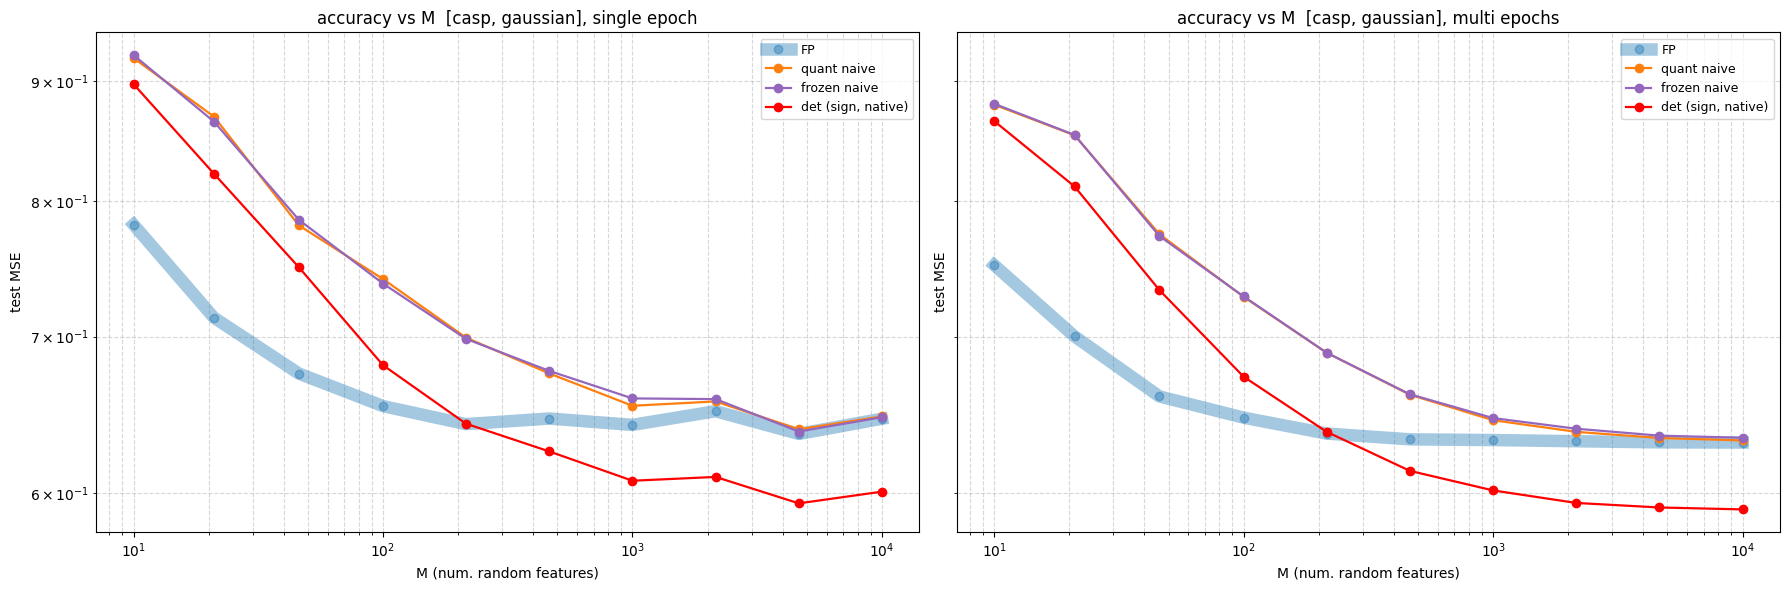

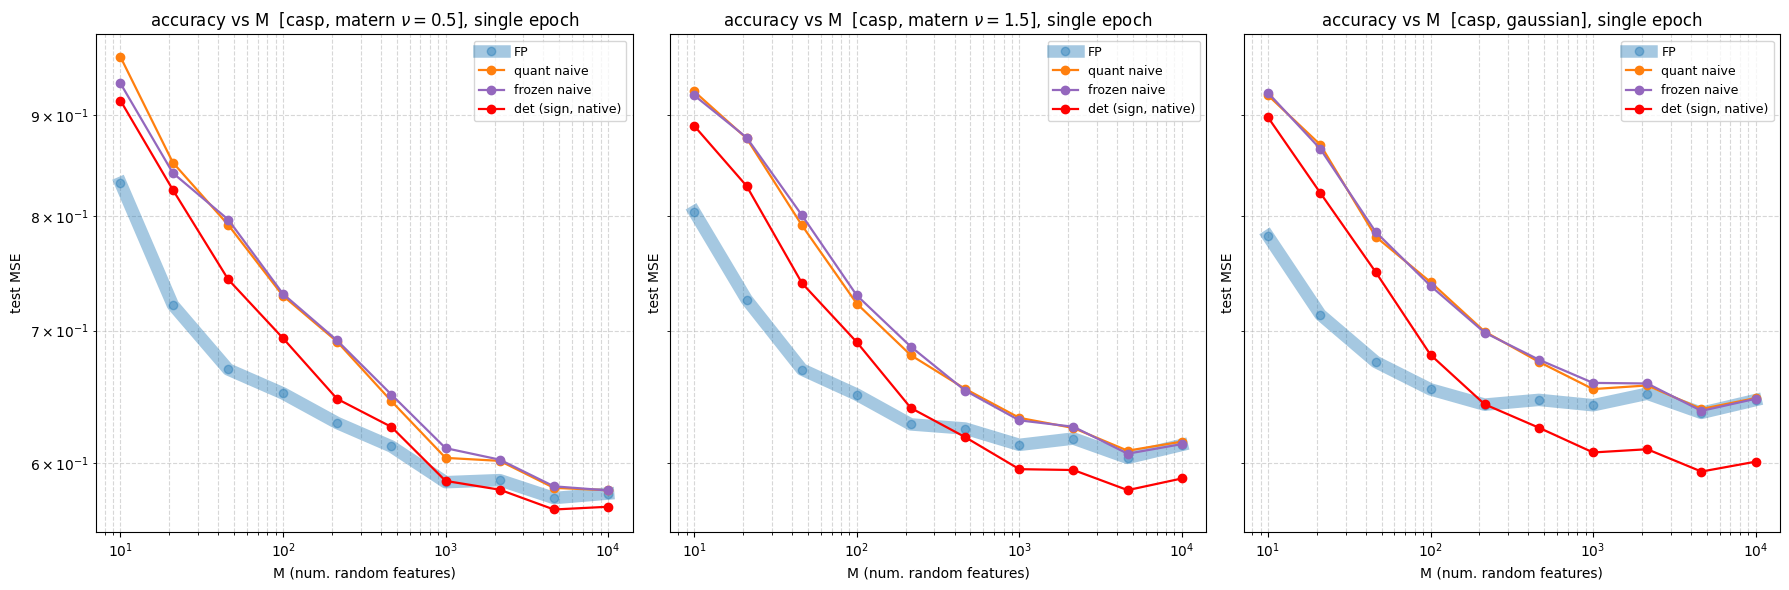

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
plot_accuracy(results_casp['casp_gau_1pass'], models=MODELS_TO_PLOT, ax = axes[0])
plot_accuracy(results_casp['casp_gau_epochs'], models=MODELS_TO_PLOT, ax = axes[1], multi_epochs=True)
plt.tight_layout()
plt.show()
plt.show()
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
plot_accuracy(results_casp['casp_mat05_1pass'], models=MODELS_TO_PLOT, ax = axes[0], nu = 0.5)
plot_accuracy(results_casp['casp_mat15_1pass'], models=MODELS_TO_PLOT, ax = axes[1], nu = 1.5)
plot_accuracy(results_casp['casp_gau_1pass'], models=MODELS_TO_PLOT, ax = axes[2])
plt.tight_layout()
plt.show()



In [96]:
X, y, sigma = load_dataset("superconduct", normalize=True, median_heuristic=True,
                           n_samples=10000, random_state=42)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)

M_values = np.logspace(1, 4, 8, dtype=int)

results_superconduct = {}
for name, cfg in CONFIGS_superconduct.items():
    print(f"=== {name} ===")
    results_superconduct[name] = run_comparison(Xtr, ytr, Xte, yte, sigma,
                                    n_reps=5, save_path=f"{name}.json", **cfg)

[load_dataset] 'superconduct' trovato in cache — caricamento da disco.
  [campionamento] Estratti 10000 / 21263 campioni.
  [normalizzazione] X e y standardizzati (media=0, std=1).

--- SUPERCONDUCT ---
Superconductivity Data
  Campioni : 21263
  Feature  : 81  (proprietà dei materiali superconduttori)
  Target   : critical_temp (temperatura critica in Kelvin)
  Fonte    : OpenML name='superconduct', version=1
  Shape X  : (10000, 81)
  Shape y  : (10000,)  |  range y = [-1.011, 4.409]
  Sigma (mediana euristica distanze) : 12.007395

=== super_gau_1pass ===
  M=    10  fp=0.5927  quant_naive=0.7241  quant_scalar=nan  frozen_naive=0.7275  frozen_scalar=nan  det=0.7233
  M=    21  fp=0.4953  quant_naive=0.6363  quant_scalar=nan  frozen_naive=0.6263  frozen_scalar=nan  det=0.6023
  M=    46  fp=0.3661  quant_naive=0.5005  quant_scalar=nan  frozen_naive=0.5024  frozen_scalar=nan  det=0.4356
  M=   100  fp=0.3200  quant_naive=0.4242  quant_scalar=nan  frozen_naive=0.4297  frozen_scalar=nan

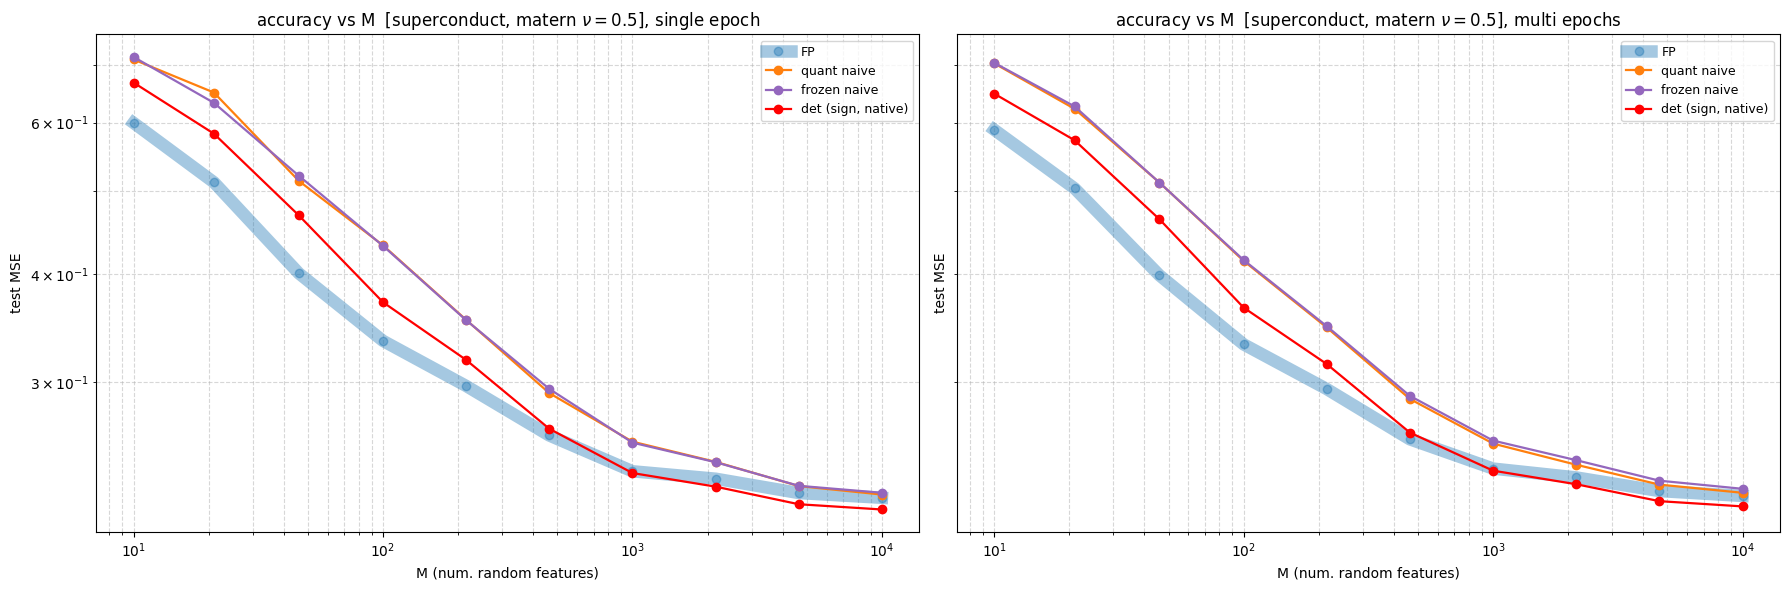

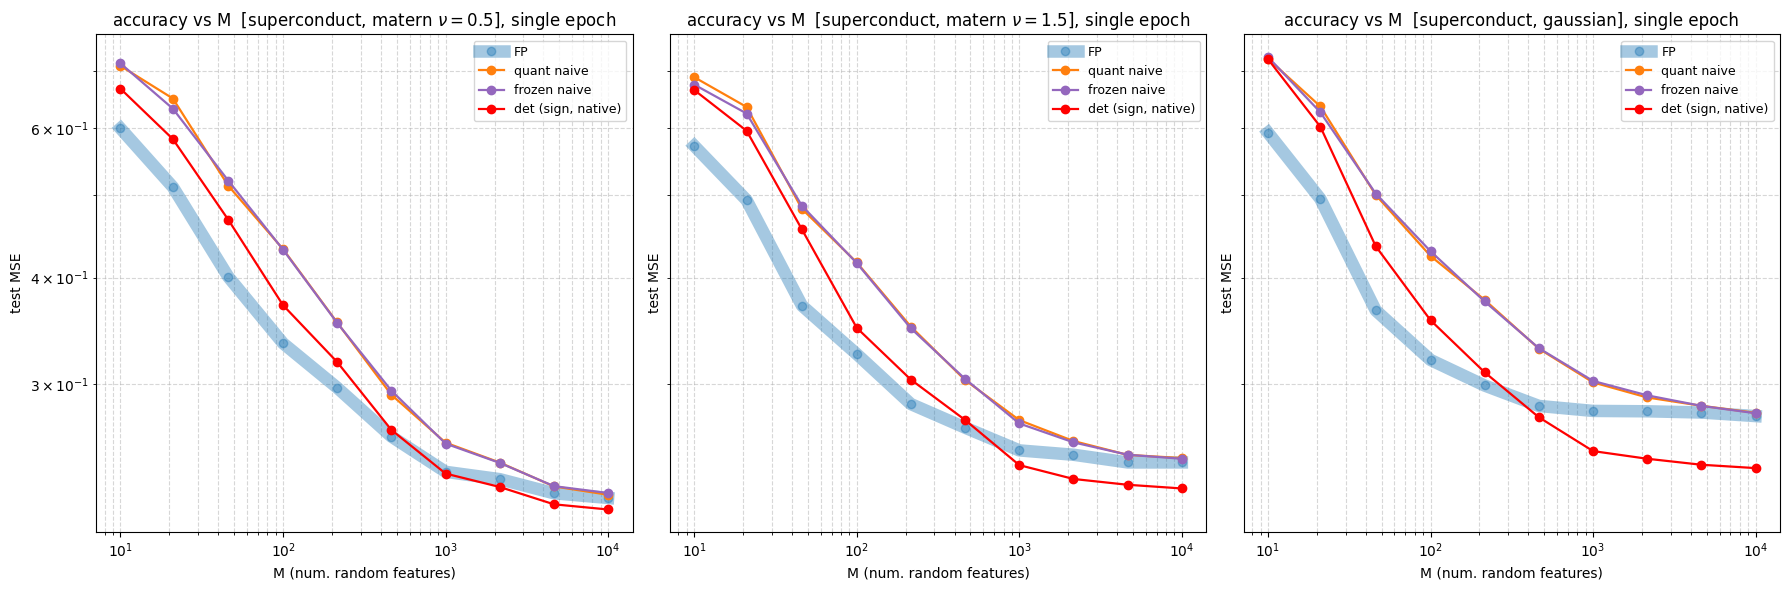

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
plot_accuracy(results_superconduct['super_mat05_1pass'], models=MODELS_TO_PLOT, ax = axes[0], nu = 0.5)
plot_accuracy(results_superconduct['super_mat_epochs'], models=MODELS_TO_PLOT, ax = axes[1], multi_epochs=True, nu = 0.5)
plt.tight_layout()
plt.show()
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
plot_accuracy(results_superconduct['super_mat05_1pass'], models=MODELS_TO_PLOT, ax = axes[0], nu = 0.5)
plot_accuracy(results_superconduct['super_mat15_1pass'], models=MODELS_TO_PLOT, ax = axes[1], nu = 1.5)
plot_accuracy(results_superconduct['super_gau_1pass'], models=MODELS_TO_PLOT, ax = axes[2])
plt.tight_layout()
plt.show()

In [10]:
_EPOCHS_CONF = dict(T=8000, batch=1, lr=0.01, decay=5e-10, bits=1)

CONFIGS_casp_conf = {
    "casp_gau_epochs_conf":  dict(M_values=_M, cfg=_EPOCHS_CONF, kernel="gaussian", dataset="casp"),
}

CONFIGS_superconduct_conf = {
    "super_mat_epochs_conf": dict(M_values=_M, cfg=_EPOCHS_CONF, kernel="matern", nu=0.5,
                             dataset="superconduct"),
}


In [13]:
X, y, sigma = load_dataset("casp", normalize=True, median_heuristic=True,
                           n_samples=10000, random_state=42)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)

M_values = np.logspace(1, 4, 8, dtype=int)

results_casp_conf = {}
for name, cfg in CONFIGS_casp_conf.items():
    print(f"=== {name} ===")
    results_casp_conf[name] = run_comparison(Xtr, ytr, Xte, yte, sigma,
                                    n_reps=5, save_path=f"{name}.json", **cfg)

[load_dataset] 'casp' trovato in cache — caricamento da disco.
  [campionamento] Estratti 10000 / 45730 campioni.
  [normalizzazione] X e y standardizzati (media=0, std=1).

--- CASP ---
Physicochemical Properties of Protein Tertiary Structure (CASP)
  Campioni : 45730
  Feature  : 9  (F1-F9: attributi fisico-chimici dalla PDB)
  Target   : RMSD (Root Mean Square Deviation, in Angstrom)
  Fonte    : OpenML ID 42903
  Shape X  : (10000, 9)
  Shape y  : (10000,)  |  range y = [-1.266, 2.175]
  Sigma (mediana euristica distanze) : 3.016089

=== casp_gau_epochs_conf ===
  M=    10  fp=0.7781  quant_naive=0.8786  quant_scalar=nan  frozen_naive=0.8885  frozen_scalar=nan  det=0.8720
  M=    21  fp=0.7410  quant_naive=0.8533  quant_scalar=nan  frozen_naive=0.8527  frozen_scalar=nan  det=0.8207
  M=    46  fp=0.6973  quant_naive=0.7861  quant_scalar=nan  frozen_naive=0.7780  frozen_scalar=nan  det=0.7491
  M=   100  fp=0.6940  quant_naive=0.7445  quant_scalar=nan  frozen_naive=0.7409  frozen_sc

<Axes: title={'center': 'accuracy vs M  [casp, gaussian], single epoch'}, xlabel='M (num. random features)', ylabel='test MSE'>

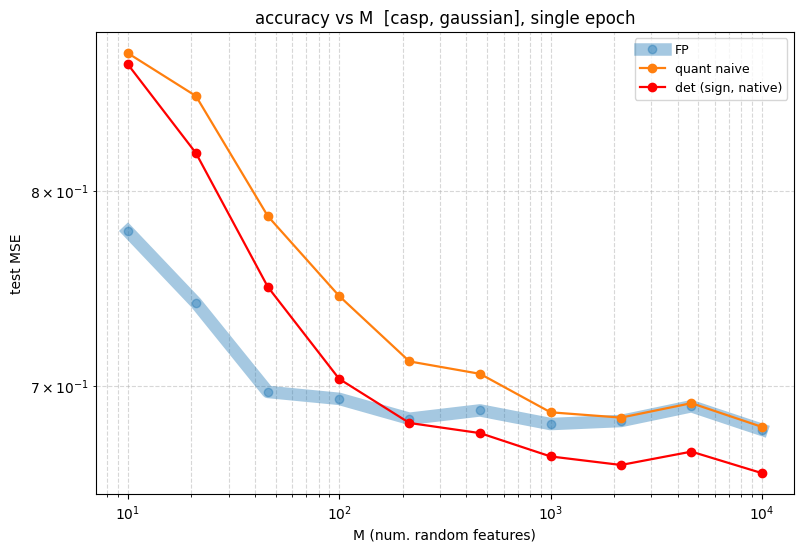

In [14]:
plot_accuracy(results_casp_conf['casp_gau_epochs_conf'], models=['fp','quant_naive', 'det'])

In [11]:
X, y, sigma = load_dataset("superconduct", normalize=True, median_heuristic=True,
                           n_samples=10000, random_state=42)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)

M_values = np.logspace(1, 4, 8, dtype=int)

results_superconduct_conf = {}
for name, cfg in CONFIGS_superconduct_conf.items():
    print(f"=== {name} ===")
    results_superconduct_conf[name] = run_comparison(Xtr, ytr, Xte, yte, sigma,
                                    n_reps=5, save_path=f"{name}.json", **cfg)

[load_dataset] 'superconduct' trovato in cache — caricamento da disco.
  [campionamento] Estratti 10000 / 21263 campioni.
  [normalizzazione] X e y standardizzati (media=0, std=1).

--- SUPERCONDUCT ---
Superconductivity Data
  Campioni : 21263
  Feature  : 81  (proprietà dei materiali superconduttori)
  Target   : critical_temp (temperatura critica in Kelvin)
  Fonte    : OpenML name='superconduct', version=1
  Shape X  : (10000, 81)
  Shape y  : (10000,)  |  range y = [-1.011, 4.409]
  Sigma (mediana euristica distanze) : 12.007395

=== super_mat_epochs_conf ===
  M=    10  fp=0.5954  quant_naive=0.7046  quant_scalar=nan  frozen_naive=0.7081  frozen_scalar=nan  det=0.6540
  M=    21  fp=0.5170  quant_naive=0.6330  quant_scalar=nan  frozen_naive=0.6327  frozen_scalar=nan  det=0.5817
  M=    46  fp=0.4337  quant_naive=0.5210  quant_scalar=nan  frozen_naive=0.5193  frozen_scalar=nan  det=0.4811
  M=   100  fp=0.3686  quant_naive=0.4248  quant_scalar=nan  frozen_naive=0.4241  frozen_scal

<Axes: title={'center': 'accuracy vs M  [superconduct, matern], single epoch'}, xlabel='M (num. random features)', ylabel='test MSE'>

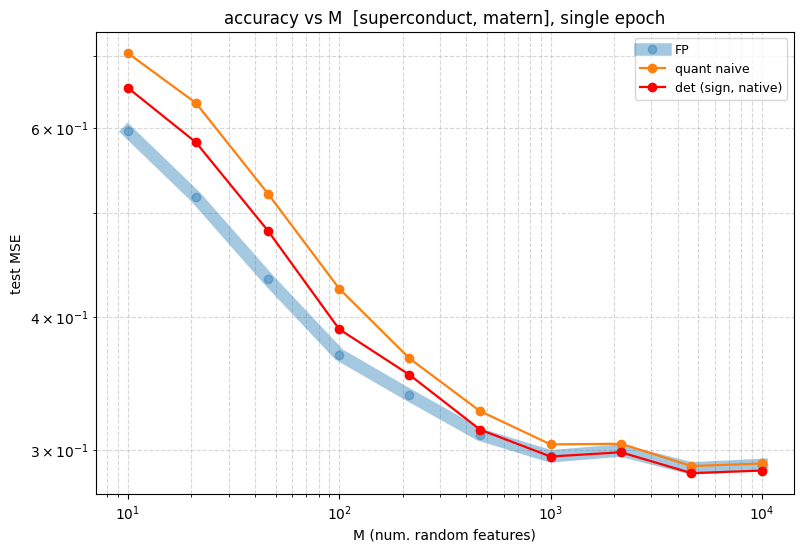

In [12]:
plot_accuracy(results_superconduct_conf['super_mat_epochs_conf'], models=['fp','quant_naive', 'det'])

In [ ]:
X, y, sigma = load_dataset("casp", normalize=True, median_heuristic=True,
                           n_samples=None, random_state=42)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
n_tr, sqrt_n = len(Xtr), np.sqrt(len(Xtr))


_M_INFO = [20, 50, 100, 200, 500, 1000]
_T = 8000

CONFIGS_muT = {
    f"casp_gau_muT{c:g}": dict(
        M_values=_M_INFO, kernel="gaussian", dataset="casp",
        cfg=dict(T=_T, batch=1, lr=c*sqrt_n/(2*_T), decay=5e-10, bits=1))
    for c in (0.25, 1.0, 4.0)
}



res_muT = {}
for name, conf in CONFIGS_muT.items():
    res_muT[name] = run_comparison(Xtr, ytr, Xte, yte, sigma,
                                   n_reps=5, save_path=f"{name}.json", **conf)
    print(name, "done")

ImportError: cannot import name 'load_dataset' from 'quantized_models_comparison' (c:\Users\2506b\OneDrive\VS\INTERNSHIP\1 - Codici\quantized_models_comparison.py)

In [32]:
res_muT

{'casp_gau_muT0.25': {'dataset': 'casp',
  'kernel': 'gaussian',
  'rho': 3.013375529008779,
  'nu': None,
  'M_values': [20, 50, 100, 200, 500, 1000],
  'd': 9,
  'n_train': 36584,
  'n_test': 9146,
  'cfg': {'T': 8000,
   'batch': 1,
   'lr': np.float64(0.002988585054001308),
   'decay': 5e-10,
   'bits': 1},
  'n_reps': 5,
  'frozen_test': 'fp',
  'sum_lr': 23.908632620754258,
  'mean': {'fp': [0.8197219050394479,
    0.7763249010362545,
    0.7845947290690323,
    0.7889310638077964,
    0.7799293905771068,
    0.7769149306404115],
   'quant_naive': [0.8862874891658414,
    0.8080975629979796,
    0.799378341000145,
    0.7966636143888113,
    0.7839991575701004,
    0.7786869247228113],
   'quant_scalar': [nan, nan, nan, nan, nan, nan],
   'frozen_naive': [0.88728797691083,
    0.8081723149521883,
    0.8004250810883718,
    0.7972377387033259,
    0.7836954726887116,
    0.7790042878734896],
   'frozen_scalar': [nan, nan, nan, nan, nan, nan],
   'det': [0.8777145265256514,
    0.

In [23]:
_M = np.logspace(1, 4, 10, dtype=int)
_CONST = dict(T=8000, batch=1, lr=0.01, decay=5e-10, bits=1)

CONFIGS_val = {
    "casp_gau":    dict(M_values=_M, cfg=_CONST, kernel="gaussian", dataset="casp"),
    "casp_mat05":  dict(M_values=_M, cfg=_CONST, kernel="matern", nu=0.5,  dataset="casp"),
    "casp_mat15":  dict(M_values=_M, cfg=_CONST, kernel="matern", nu=1.5,  dataset="casp"),
    "super_gau":   dict(M_values=_M, cfg=_CONST, kernel="gaussian", dataset="superconduct"),
    "super_mat05": dict(M_values=_M, cfg=_CONST, kernel="matern", nu=0.5,  dataset="superconduct"),
}

res_val = {}
for ds in ("casp", "superconduct"):
    X, y, sigma = load_dataset(ds, normalize=True, median_heuristic=True,
                               n_samples=10000, random_state=42)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
    for name, conf in CONFIGS_val.items():
        if conf["dataset"] != ds:
            continue
        res_val[name] = run_comparison(Xtr, ytr, Xte, yte, sigma,
                                       n_reps=5, save_path=f"{name}.json", **conf)
        print(name, "done")

[load_dataset] 'casp' trovato in cache — caricamento da disco.
  [campionamento] Estratti 10000 / 45730 campioni.
  [normalizzazione] X e y standardizzati (media=0, std=1).

--- CASP ---
Physicochemical Properties of Protein Tertiary Structure (CASP)
  Campioni : 45730
  Feature  : 9  (F1-F9: attributi fisico-chimici dalla PDB)
  Target   : RMSD (Root Mean Square Deviation, in Angstrom)
  Fonte    : OpenML ID 42903
  Shape X  : (10000, 9)
  Shape y  : (10000,)  |  range y = [-1.266, 2.175]
  Sigma (mediana euristica distanze) : 3.016089

  M=    10  fp=0.7781  quant_naive=0.8786  quant_scalar=2064.7104  frozen_naive=0.8885  frozen_scalar=1715.5886  det=0.8720
  M=    21  fp=0.7410  quant_naive=0.8533  quant_scalar=0.9906  frozen_naive=0.8527  frozen_scalar=1.3502  det=0.8207
  M=    46  fp=0.6973  quant_naive=0.7861  quant_scalar=0.7140  frozen_naive=0.7780  frozen_scalar=0.7090  det=0.7491
  M=   100  fp=0.6940  quant_naive=0.7445  quant_scalar=0.7040  frozen_naive=0.7409  frozen_scal

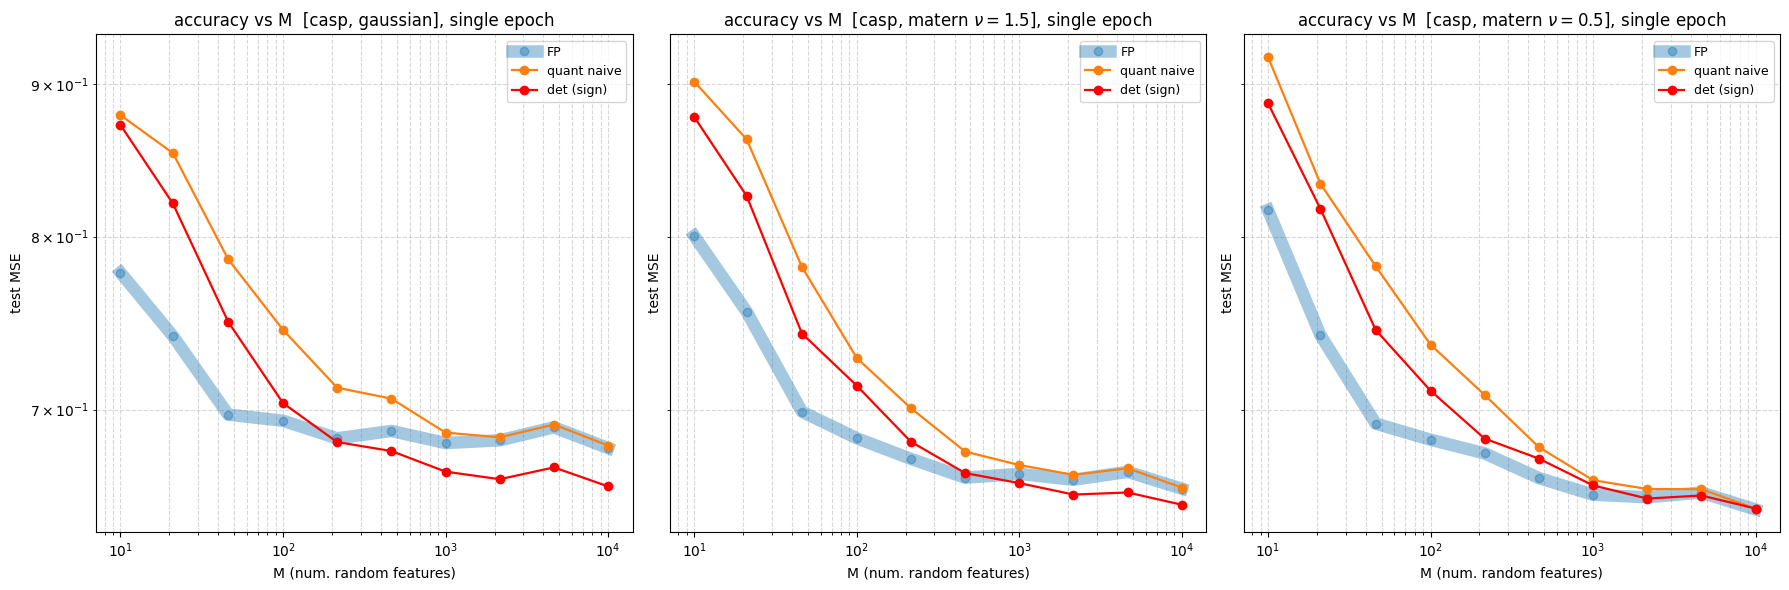

In [30]:
MODELS_TO_PLOT5 = ['fp', 'quant_naive', 'det']

fig5, axes5 = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
plot_accuracy(res_val['casp_gau'], models=MODELS_TO_PLOT5, ax = axes5[0])
plot_accuracy(res_val['casp_mat05'], models=MODELS_TO_PLOT5, ax = axes5[2], nu = 0.5)
plot_accuracy(res_val['casp_mat15'], models=MODELS_TO_PLOT5, ax = axes5[1], nu = 1.5)
plt.tight_layout()
plt.show()

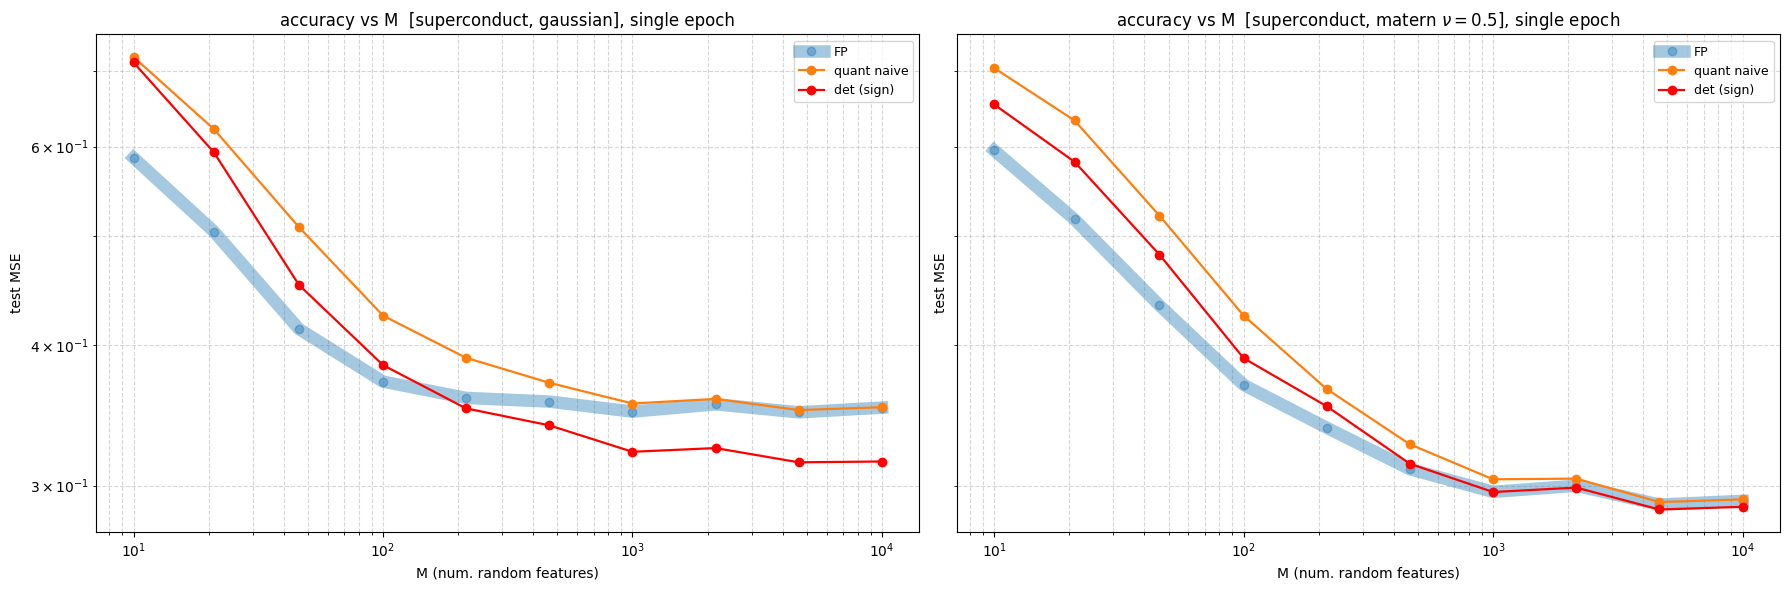

In [31]:
MODELS_TO_PLOT5 = ['fp', 'quant_naive', 'det']

fig6, axes6 = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
plot_accuracy(res_val['super_gau'], models=MODELS_TO_PLOT5, ax = axes6[0])
plot_accuracy(res_val['super_mat05'], models=MODELS_TO_PLOT5, ax = axes6[1], nu = 0.5)
plt.tight_layout()
plt.show()

In [ ]:
_CONST_PERM = dict(_CONST, single_pass=True)   # T=8000, batch=1 -> Tb = n

CONFIGS_perm = {
    "casp_gau_perm":   dict(M_values=_M, cfg=_CONST_PERM, kernel="gaussian", dataset="casp"),
    "super_mat05_perm": dict(M_values=_M, cfg=_CONST_PERM, kernel="matern", nu=0.5,
                             dataset="superconduct"),
}
_M = np.logspace(1, 4, 10, dtype=int)
_CONST      = dict(T=8000, batch=1, lr=0.01, decay=5e-10, bits=1)
_CONST_PERM = dict(_CONST, single_pass=True)

KERNELS = [("gau", dict(kernel="gaussian")),
           ("mat05", dict(kernel="matern", nu=0.5)),
           ("mat15", dict(kernel="matern", nu=1.5))]

CONFIGS = {}
for ds in ("casp", "superconduct"):
    tag = "casp" if ds == "casp" else "super"
    for kname, kw in KERNELS:
        CONFIGS[f"{tag}_{kname}"] = dict(M_values=_M, cfg=_CONST, dataset=ds, **kw)
        CONFIGS[f"{tag}_{kname}_perm"] = dict(M_values=_M, cfg=_CONST_PERM, dataset=ds, **kw)


RES = {}
for ds in ("casp", "superconduct"):
    X, y, sigma = load_dataset(ds, normalize=True, median_heuristic=True,
                               n_samples=10000, random_state=42)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
    for name, conf in CONFIGS.items():
        if conf["dataset"] != ds:
            continue
        RES[name] = run_comparison(Xtr, ytr, Xte, yte, sigma, n_reps=5,
                                   save_path=f"v2_{name}.json", **conf)
        print(name, "done")



def curve(res, est):
    node = res[est]
    return np.asarray(node["mse_mean"] if isinstance(node, dict) else node, dtype=float)


def plot_group(tag, kernels, title, outfile):
    fig, axes = plt.subplots(1, len(kernels), figsize=(5.5 * len(kernels), 4.2))
    for ax, (kname, label) in zip(np.atleast_1d(axes), kernels):
        r_rep, r_per = RES[f"{tag}_{kname}"], RES[f"{tag}_{kname}_perm"]
        ax.semilogx(_M, curve(r_rep, "quant_naive") - curve(r_rep, "fp"),
                    "o-", label="SQ, with replacement")
        ax.semilogx(_M, curve(r_per, "frozen_naive") - curve(r_per, "fp"),
                    "s--", label="FQ, single pass")
        ax.axhline(0, color="k", lw=0.8)
        ax.set_title(label)
        ax.set_xlabel("M (num. random features)")
        ax.set_ylabel("excess over FP")
        ax.grid(True, which="both", ls=":", alpha=0.5)
        ax.legend()
    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(outfile, dpi=150)
    print("saved", outfile)


LBL = [("gau", "gaussian"), ("mat15", r"matern $\nu=1.5$"), ("mat05", r"matern $\nu=0.5$")]
os.makedirs("pics", exist_ok=True)
plot_group("casp",  LBL, "CASP",         "pics/perm_vs_repl_CASP.png")
plot_group("super", LBL, "SUPERCONDUCT", "pics/perm_vs_repl_SUPER.png")

In [39]:
import json, os
import numpy as np
import matplotlib.pyplot as plt

_M = np.logspace(1, 4, 10, dtype=int)

RES = {}
for f in os.listdir("."):
    if f.startswith("v2_") and f.endswith(".json"):
        RES[f[3:-5]] = json.load(open(f))

r = RES["casp_gau"]
print(type(r), list(r.keys())[:20])

<class 'dict'> ['dataset', 'kernel', 'rho', 'nu', 'M_values', 'd', 'n_train', 'n_test', 'cfg', 'n_reps', 'frozen_test', 'sum_lr', 'mean', 'std', 'diagnostics', 'stored_bits']


In [40]:
print(list(RES["casp_gau"]["mean"].keys()))

['fp', 'quant_naive', 'quant_scalar', 'frozen_naive', 'frozen_scalar', 'det']


In [41]:
print(RES["casp_gau"]["cfg"], RES["casp_gau_perm"]["cfg"])
print(RES["casp_gau"]["sum_lr"], RES["casp_gau_perm"]["sum_lr"])

{'T': 8000, 'batch': 1, 'lr': 0.01, 'decay': 5e-10, 'bits': 1} {'T': 8000, 'batch': 1, 'lr': 0.01, 'decay': 5e-10, 'bits': 1, 'single_pass': True}
79.99984002042659 79.99984002042659


In [44]:
def curve(res, est):
    return np.asarray(res["mean"][est], dtype=float)


print(curve(RES["casp_gau"], "fp") - curve(RES["casp_gau_perm"], "fp"))

[-5.86599071e-03  2.68831566e-04 -2.23611136e-03 -2.96657209e-05
  1.72368610e-03  2.43705959e-03  3.46276745e-03 -2.68914807e-04
  1.22429137e-02 -1.46784662e-03]


In [45]:
import inspect, quantized_models_comparison as q
src = inspect.getsource(q)
i = src.find("single_pass")
print(src[max(0,i-600):i+600])

def estimate_Dbar(sampler, X, bits, chunk=2048):
    L = 2 ** bits
    acc = np.zeros(sampler.M)
    for a in range(0, X.shape[0], chunk):
        p = ((np.cos(X[a:a + chunk] @ sampler.w.T + sampler.u) + 1.0) / 2.0 * (L - 1)) % 1.0
        acc += (p * (1.0 - p)).sum(axis=0)
    return (2.0 / sampler.M) * (2.0 / (L - 1)) ** 2 * (acc / X.shape[0])


# ---------------------------------------------------------------------------
# 2. Training e valutazione
# ---------------------------------------------------------------------------

# FUNCTION: _batches
# INPUTS:  n, cfg, rng
# OUTPUTS: (t, idx). single_pass=True -> permutazione senza rimpiazzo: ogni
#          campione usato una volta, streaming e frozen coincidono in legge
def _batches(n, cfg, rng):
    if cfg.get("single_pass", False):
        perm = rng.permutation(n)
        for t in range(min(cfg["T"], n // cfg["batch"])):
            yield t, perm[t * cfg["batch"]:(t + 1) * cfg["batch"]]
    else:
        for t in range(cfg["T"]):
 

saved pics/perm_vs_repl_CASP.png
saved pics/perm_vs_repl_SUPER.png


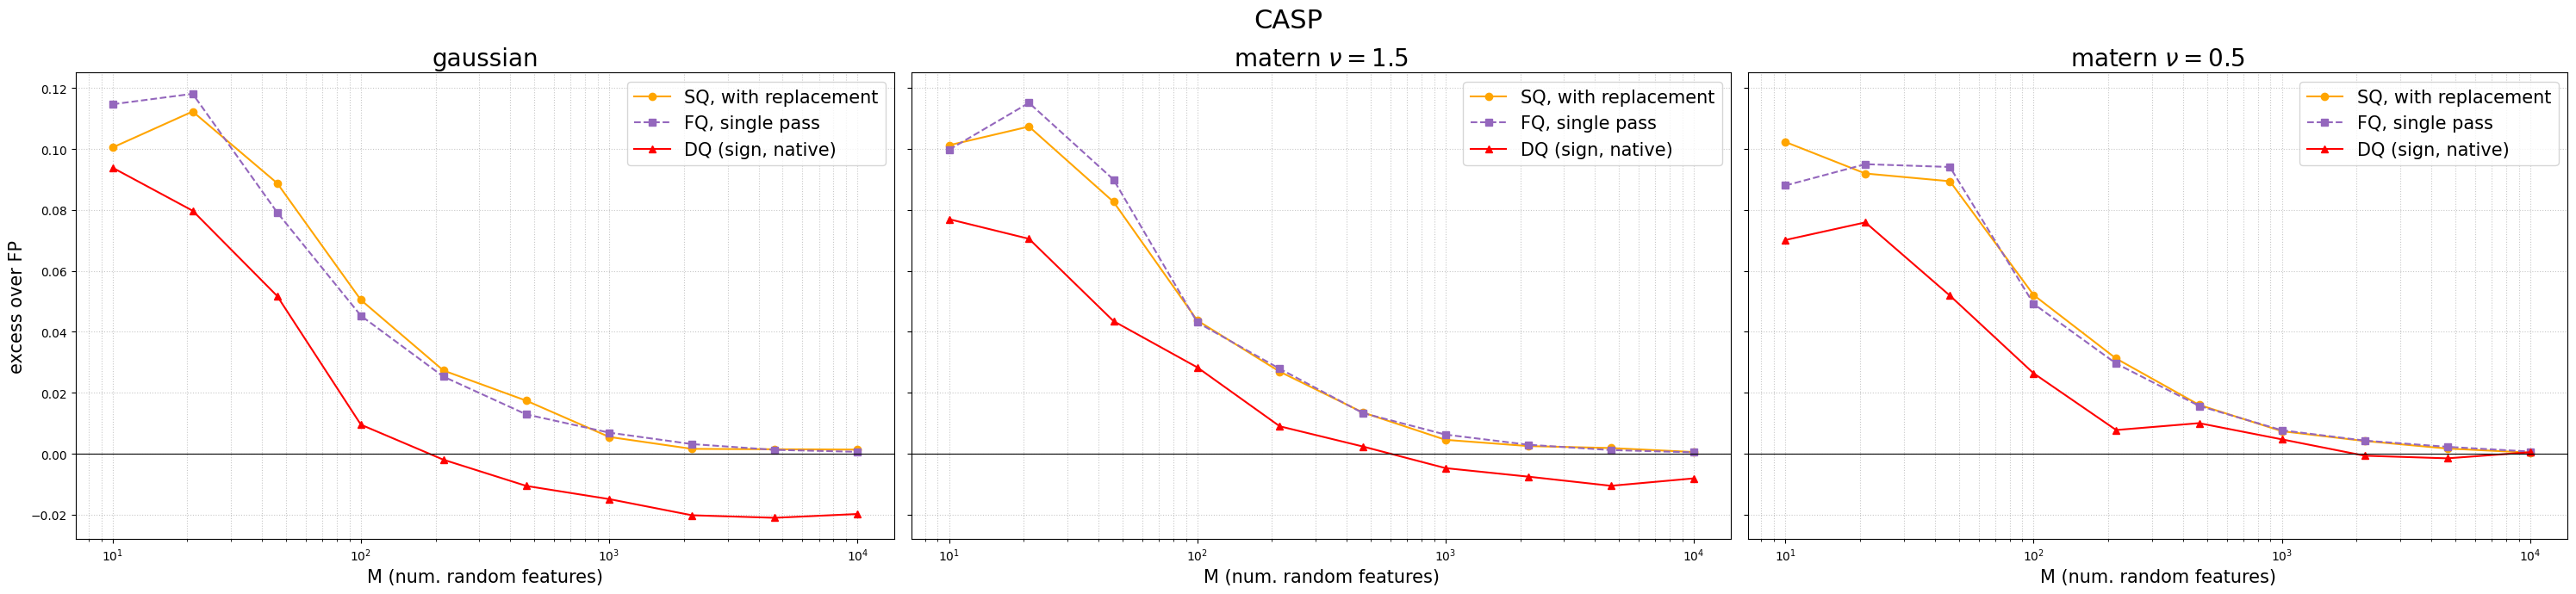

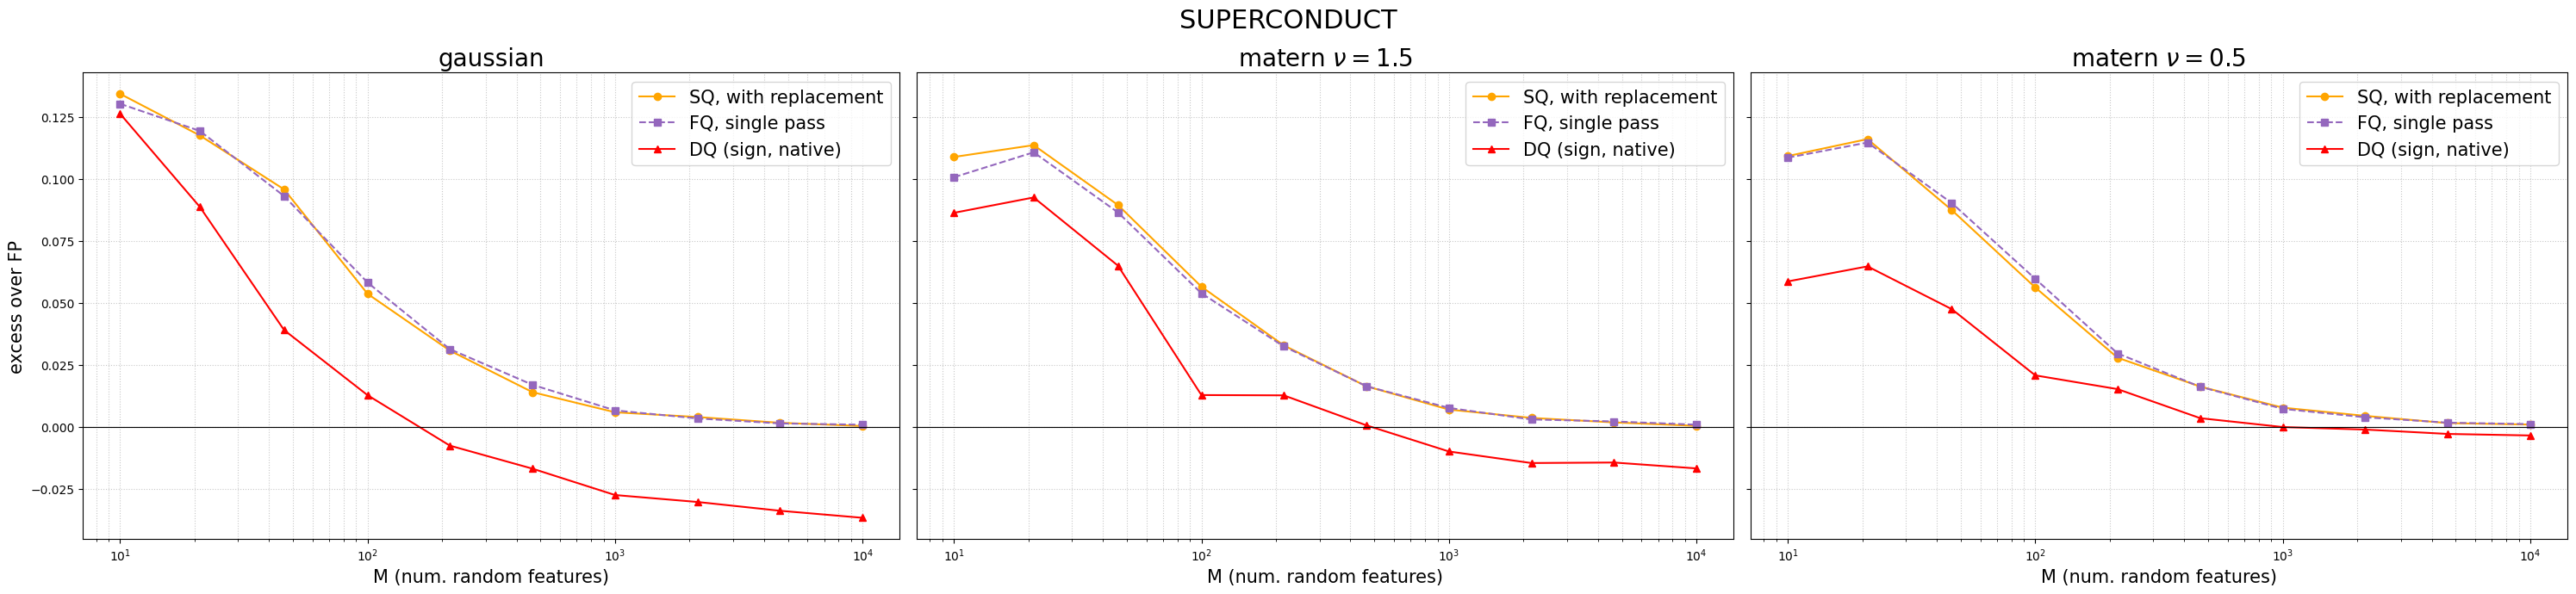

In [62]:
from matplotlib import legend

RES = {}
for f in os.listdir("."):
    if f.startswith("v2_") and f.endswith(".json"):
        RES[f[3:-5]] = json.load(open(f))

def curve(res, est):
    return np.asarray(res["mean"][est], dtype=float)

def plot_group(tag, kernels, title, outfile):
    n = len(kernels)
    fig, axes = plt.subplots(1, n, figsize=(10.0 * n, 7), sharey=True)
    axes = np.atleast_1d(axes)
    lo, hi = np.inf, -np.inf
    for ax, (kname, label) in zip(axes, kernels):
        r_rep, r_per = RES[f"{tag}_{kname}"], RES[f"{tag}_{kname}_perm"]
        fp = curve(r_rep, "fp")
        series = [(curve(r_rep, "quant_naive") - fp, "o-",  "orange", "SQ, with replacement"),
                  (curve(r_per, "frozen_naive") - curve(r_per, "fp"), "s--", "#9467bd", "FQ, single pass"),
                  (curve(r_rep, "det") - fp, "^-", "red", "DQ (sign, native)")]
        for d, sty, col, lab in series:
            ax.semilogx(_M, d, sty, color=col, label=lab)
            lo, hi = min(lo, d.min()), max(hi, d.max())
        ax.axhline(0, color="k", lw=0.8)
        ax.set_title(label, fontsize = 20)
        ax.set_xlabel("M (num. random features)", fontsize =15)
        ax.grid(True, which="both", ls=":", alpha=0.7)
        ax.legend(fontsize =15)
    pad = 0.05 * (hi - lo)
    axes[0].set_ylim(lo - pad, hi + pad)
    axes[0].set_ylabel("excess over FP", fontsize = 15)

    fig.suptitle(title, fontsize = 22)
    fig.tight_layout()
    fig.savefig(outfile, dpi=150)
    print("saved", outfile)

LBL = [("gau", "gaussian"), ("mat15", r"matern $\nu=1.5$"), ("mat05", r"matern $\nu=0.5$")]
os.makedirs("pics", exist_ok=True)
plot_group("casp",  LBL, "CASP",         "pics/perm_vs_repl_CASP.png")
plot_group("super", LBL, "SUPERCONDUCT", "pics/perm_vs_repl_SUPER.png")

In [57]:
for tag in ("casp", "super"):
    for kname, _ in LBL:
        d_sq = curve(RES[f"{tag}_{kname}"], "quant_naive") - curve(RES[f"{tag}_{kname}"], "fp")
        d_fq = curve(RES[f"{tag}_{kname}_perm"], "frozen_naive") - curve(RES[f"{tag}_{kname}_perm"], "fp")
        print(f"{tag}_{kname}: max|diff| = {np.abs(d_sq - d_fq).max():.4f}")

casp_gau: max|diff| = 0.0142
casp_mat15: max|diff| = 0.0078
casp_mat05: max|diff| = 0.0143
super_gau: max|diff| = 0.0045
super_mat15: max|diff| = 0.0082
super_mat05: max|diff| = 0.0035


saved pics/perm_vs_repl_CASP.png
saved pics/perm_vs_repl_SUPER.png


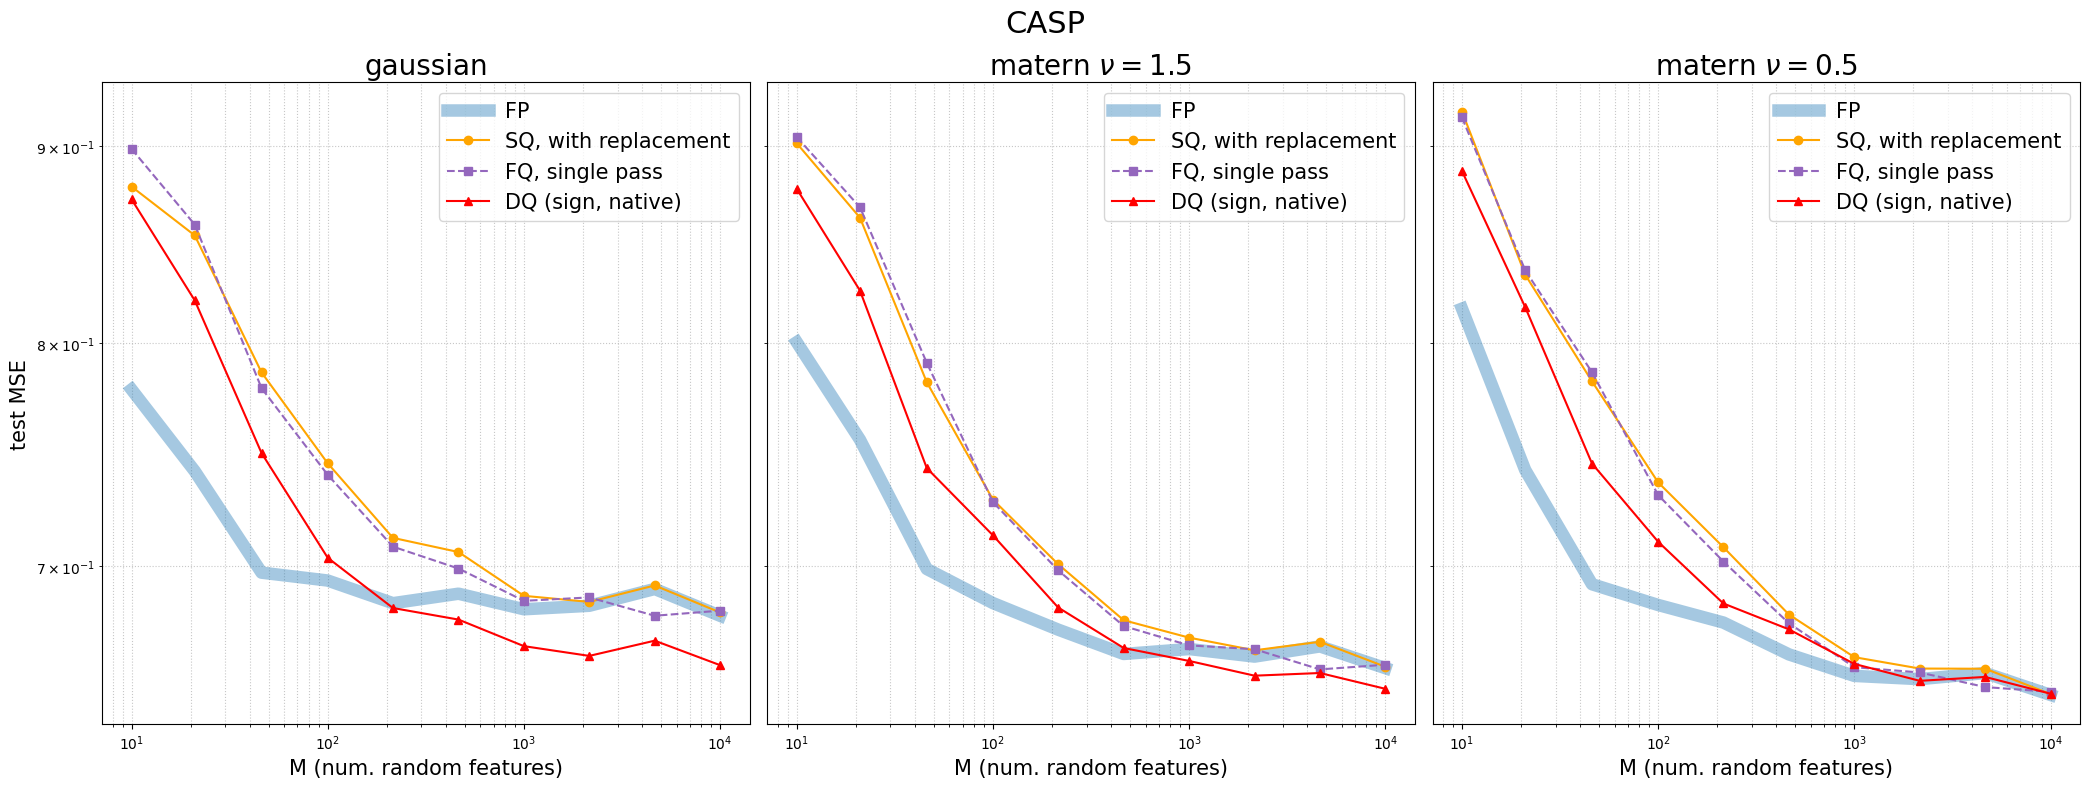

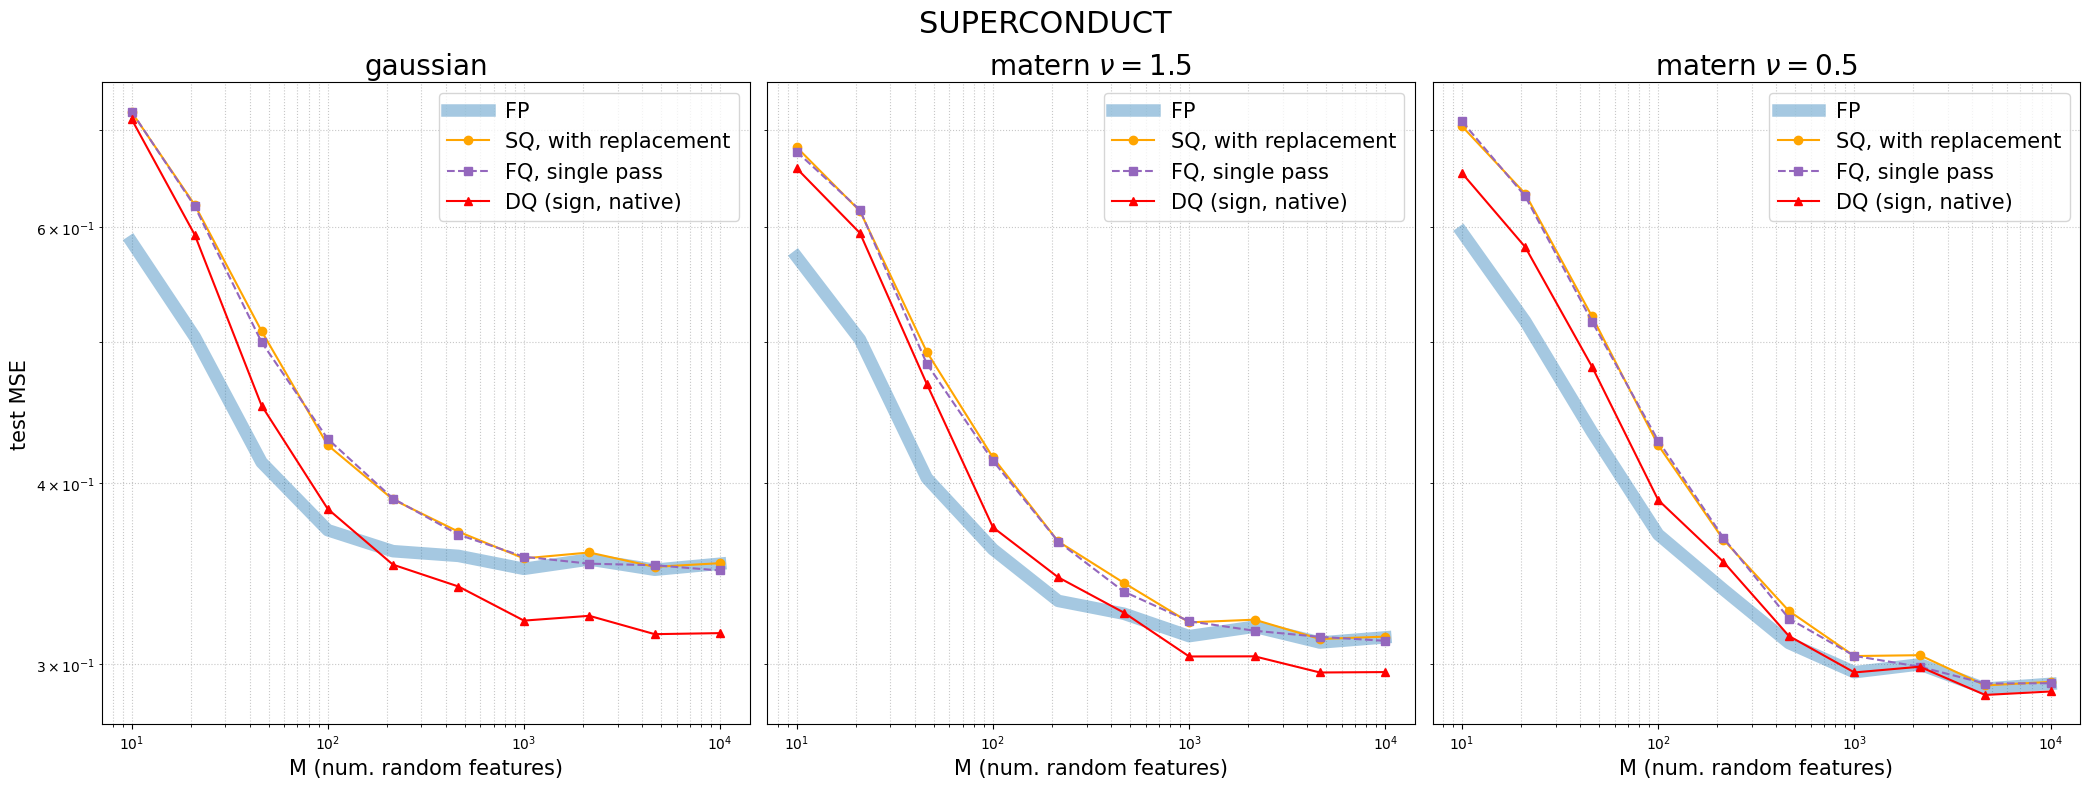

In [71]:
def plot_group(tag, kernels, title, outfile):
    n = len(kernels)
    fig, axes = plt.subplots(1, n, figsize=(7.0 * n, 8), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, (kname, label) in zip(axes, kernels):
        r_rep, r_per = RES[f"{tag}_{kname}"], RES[f"{tag}_{kname}_perm"]
        ax.loglog(_M, curve(r_rep, "fp"), "-", color="#1f77b4", lw=9, alpha=0.4,
                   label="FP")
        ax.loglog(_M, curve(r_rep, "quant_naive"), "o-", color="orange",
                  label="SQ, with replacement")
        ax.loglog(_M, curve(r_per, "frozen_naive"), "s--", color="#9467bd",
                  label="FQ, single pass")
        ax.loglog(_M, curve(r_rep, "det"), "^-", color="red", label="DQ (sign, native)")
        ax.set_title(label, fontsize=20)
        ax.set_xlabel("M (num. random features)", fontsize=15)
        ax.grid(True, which="both", ls=":", alpha=0.7)
        ax.legend(fontsize=15)
    axes[0].set_ylabel("test MSE", fontsize=15)
    fig.suptitle(title, fontsize=22)
    fig.tight_layout()
    fig.savefig(outfile, dpi=150)
    print("saved", outfile)


LBL = [("gau", "gaussian"), ("mat15", r"matern $\nu=1.5$"), ("mat05", r"matern $\nu=0.5$")]
os.makedirs("pics", exist_ok=True)
plot_group("casp",  LBL, "CASP",         "pics/perm_vs_repl_CASP.png")
plot_group("super", LBL, "SUPERCONDUCT", "pics/perm_vs_repl_SUPER.png")

In [ ]:
n_tr = 8000
_M       = np.logspace(1, 4, 10, dtype=int)


_SP = dict(T=n_tr,                    batch=1, lr=1/np.sqrt(n_tr)/2, decay=0.0, bits=1)
_MP = dict(T=int(n_tr*np.sqrt(n_tr)), batch=1, lr=1/n_tr/2,          decay=0.0, bits=1)
print(_SP, _MP)

X, y, sigma = load_dataset("casp", normalize=True, median_heuristic=True,
                           n_samples=10000, random_state=42)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
assert len(Xtr) == n_tr, f"n_train = {len(Xtr)}, update n_tr"

r = run_comparison(Xtr, ytr, Xte, yte, sigma, n_reps=1, M_values=[100],
                   cfg=_SP, kernel="gaussian", dataset="casp")
print("sum_lr =", r["sum_lr"], "(expected 44.72)")
print(r["mean"])

{'T': 8000, 'batch': 1, 'lr': np.float64(0.005590169943749474), 'decay': 0.0, 'bits': 1} {'T': 715541, 'batch': 1, 'lr': 6.25e-05, 'decay': 0.0, 'bits': 1}
[load_dataset] 'casp' trovato in cache — caricamento da disco.
  [campionamento] Estratti 10000 / 45730 campioni.
  [normalizzazione] X e y standardizzati (media=0, std=1).

--- CASP ---
Physicochemical Properties of Protein Tertiary Structure (CASP)
  Campioni : 45730
  Feature  : 9  (F1-F9: attributi fisico-chimici dalla PDB)
  Target   : RMSD (Root Mean Square Deviation, in Angstrom)
  Fonte    : OpenML ID 42903
  Shape X  : (10000, 9)
  Shape y  : (10000,)  |  range y = [-1.266, 2.175]
  Sigma (mediana euristica distanze) : 3.016089

  M=   100  fp=0.7150  quant_naive=0.7458  quant_scalar=0.7173  frozen_naive=0.7459  frozen_scalar=0.7168  det=0.7316
sum_lr = 44.721359549995796 (atteso 44.72)
{'fp': [0.7149524817562146], 'quant_naive': [0.7458025976681818], 'quant_scalar': [0.7172727960361639], 'frozen_naive': [0.745932898048521]

In [74]:
CONFIGS_SP = {
    "casp_gau_sp":    dict(M_values=_M, cfg=_SP, kernel="gaussian", dataset="casp"),
    "casp_mat05_sp":  dict(M_values=_M, cfg=_SP, kernel="matern", nu=0.5, dataset="casp"),
    "casp_mat15_sp":  dict(M_values=_M, cfg=_SP, kernel="matern", nu=1.5, dataset="casp"),
    "super_gau_sp":   dict(M_values=_M, cfg=_SP, kernel="gaussian", dataset="superconduct"),
    "super_mat05_sp": dict(M_values=_M, cfg=_SP, kernel="matern", nu=0.5, dataset="superconduct"),
    "super_mat15_sp": dict(M_values=_M, cfg=_SP, kernel="matern", nu=1.5, dataset="superconduct"),
}

RES3 = {}
for ds in ("casp", "superconduct"):
    X, y, sigma = load_dataset(ds, normalize=True, median_heuristic=True,
                               n_samples=10000, random_state=42)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
    for name, conf in CONFIGS_SP.items():
        if conf["dataset"] != ds:
            continue
        RES3[name] = run_comparison(Xtr, ytr, Xte, yte, sigma, n_reps=5,
                                    save_path=f"v3_{name}.json", **conf)
        print(name, "done")

[load_dataset] 'casp' trovato in cache — caricamento da disco.
  [campionamento] Estratti 10000 / 45730 campioni.
  [normalizzazione] X e y standardizzati (media=0, std=1).

--- CASP ---
Physicochemical Properties of Protein Tertiary Structure (CASP)
  Campioni : 45730
  Feature  : 9  (F1-F9: attributi fisico-chimici dalla PDB)
  Target   : RMSD (Root Mean Square Deviation, in Angstrom)
  Fonte    : OpenML ID 42903
  Shape X  : (10000, 9)
  Shape y  : (10000,)  |  range y = [-1.266, 2.175]
  Sigma (mediana euristica distanze) : 3.016089

  M=    10  fp=0.7887  quant_naive=0.8770  quant_scalar=2.7515  frozen_naive=0.8871  frozen_scalar=2.3655  det=0.8689
  M=    21  fp=0.7607  quant_naive=0.8512  quant_scalar=0.7722  frozen_naive=0.8522  frozen_scalar=0.7745  det=0.8232
  M=    46  fp=0.7184  quant_naive=0.7853  quant_scalar=0.7271  frozen_naive=0.7813  frozen_scalar=0.7240  det=0.7595
  M=   100  fp=0.7174  quant_naive=0.7520  quant_scalar=0.7229  frozen_naive=0.7482  frozen_scalar=0.7

saved pics/theory_validation_CASP.png
saved pics/theory_validation_SUPER.png


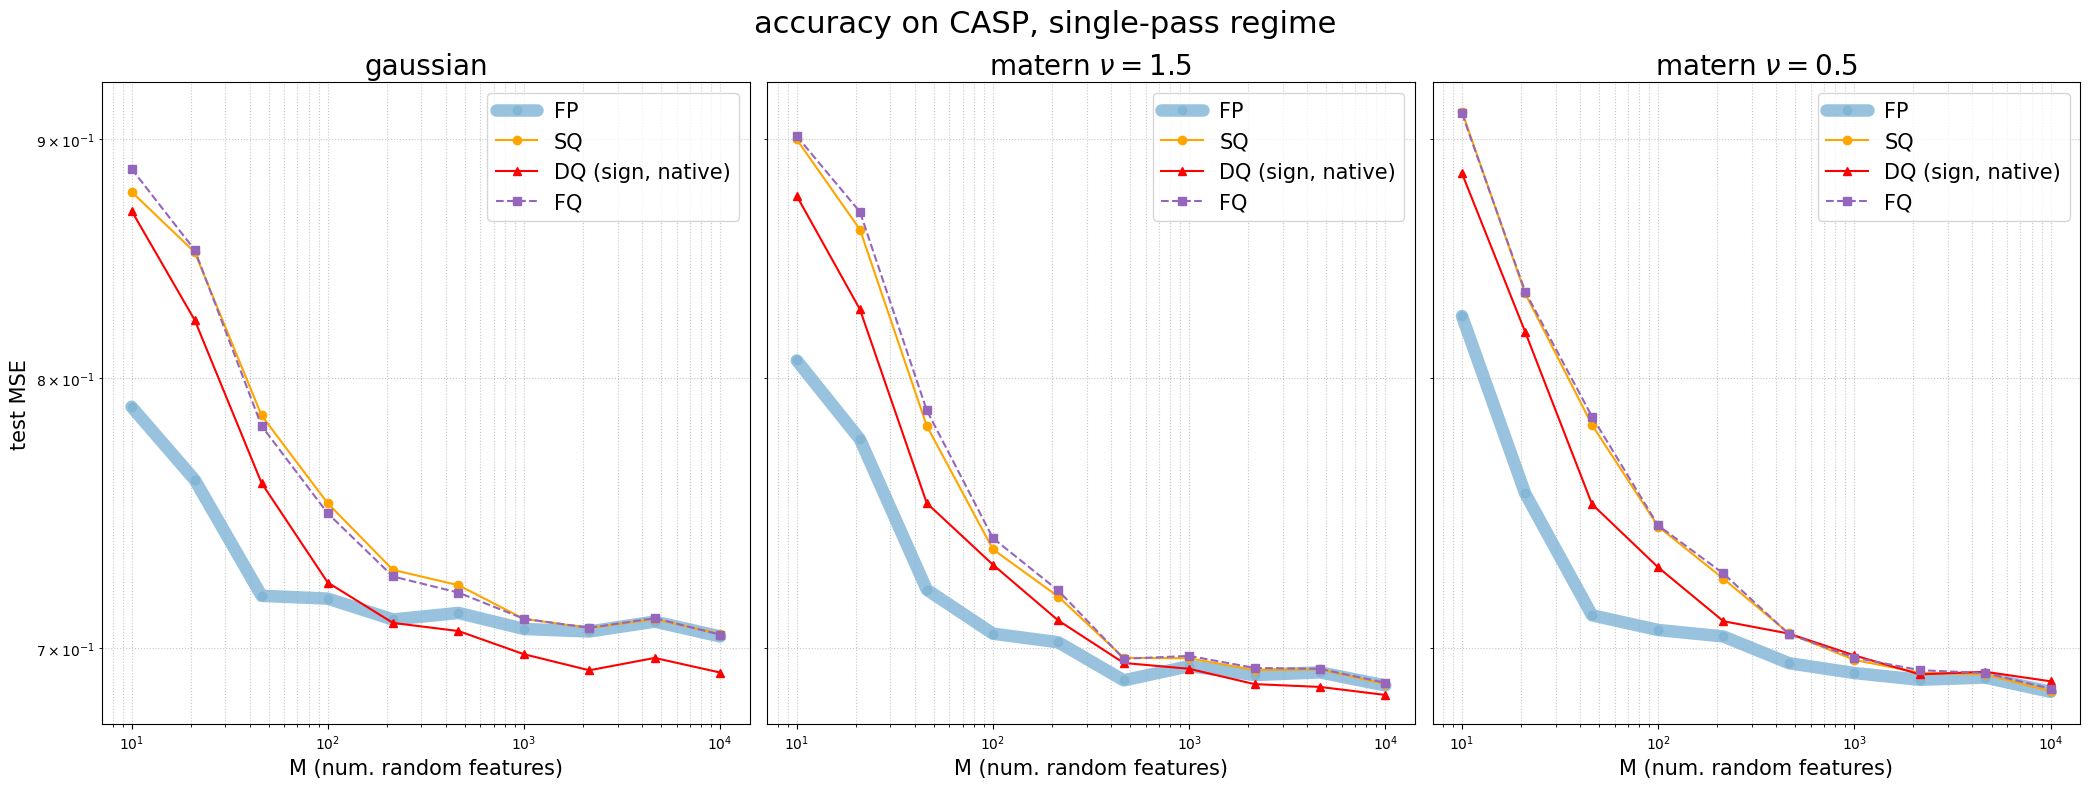

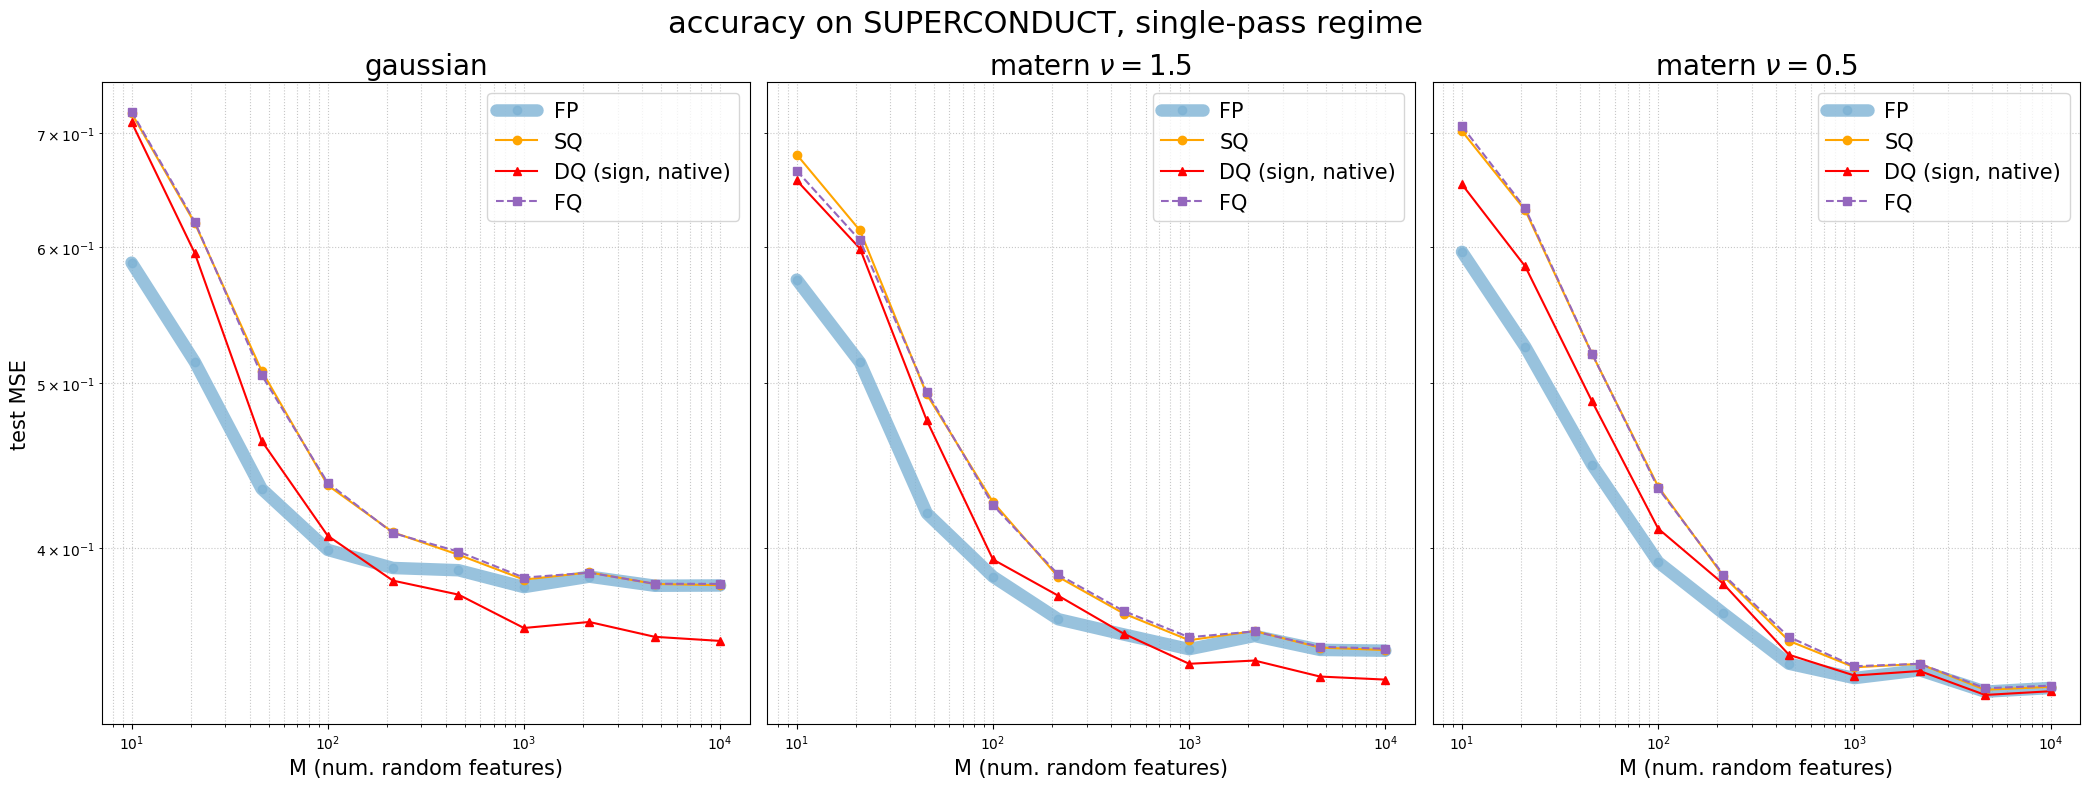

In [111]:
def curve(res, est):
    return np.asarray(res["mean"][est], dtype=float)

def plot_val(tag, kernels, title, outfile, Mg=_M):
    n = len(kernels)
    fig, axes = plt.subplots(1, n, figsize=(7.0*n, 8), sharey=True)
    for ax, (kname, label) in zip(np.atleast_1d(axes), kernels):
        r = RES3[f"{tag}_{kname}_sp"]
        ax.loglog(Mg, curve(r, "fp"), "o-", color="#7fb3d5", lw=9, alpha=0.8,
                  solid_capstyle="round", label="FP")
        ax.loglog(Mg, curve(r, "quant_naive"), "o-", color="orange", label="SQ")
        ax.loglog(Mg, curve(r, "det"), "^-", color="red", label="DQ (sign, native)")
        ax.loglog(Mg, curve(r, "frozen_naive"), "s--", color="#9467bd", label="FQ")
        ax.set_title(label, fontsize=20)
        ax.set_xlabel("M (num. random features)", fontsize=15)
        ax.grid(True, which="both", ls=":", alpha=0.7)
        ax.legend(fontsize=15)
    np.atleast_1d(axes)[0].set_ylabel("test MSE", fontsize=15)
    fig.suptitle('accuracy on ' + title + ', single-pass regime', fontsize=22)
    fig.tight_layout(); fig.savefig(outfile, dpi=150); print("saved", outfile)

LBL = [("gau", "gaussian"), ("mat15", r"matern $\nu=1.5$"), ("mat05", r"matern $\nu=0.5$")]
os.makedirs("pics", exist_ok=True)
plot_val("casp",  LBL, "CASP",         "pics/theory_validation_CASP.png")
plot_val("super", LBL, "SUPERCONDUCT", "pics/theory_validation_SUPER.png")

In [78]:
w = (_M >= 46) & (_M <= 1000)
for name in CONFIGS_SP:
    r = RES3[name]
    d = curve(r, "quant_naive") - curve(r, "fp")
    print(f"{name}: slope = {np.polyfit(np.log(_M[w]), np.log(d[w]), 1)[0]:.2f}")

casp_gau_sp: slope = -0.93
casp_mat05_sp: slope = -0.88
casp_mat15_sp: slope = -0.99
super_gau_sp: slope = -0.97
super_mat05_sp: slope = -0.88
super_mat15_sp: slope = -0.92


In [79]:
import time
t0 = time.time()
run_comparison(Xtr, ytr, Xte, yte, sigma, n_reps=1, M_values=[100],
               cfg=_MP, kernel="gaussian", dataset="casp")
print(f"{time.time()-t0:.0f} s")

  M=   100  fp=0.7161  quant_naive=0.7487  quant_scalar=0.7171  frozen_naive=0.7492  frozen_scalar=0.7175  det=0.7329
131 s


In [81]:
_M_SHORT = np.logspace(1, 3, 5, dtype=int)

CONFIGS_MP = {
    "casp_gau_mp":    dict(M_values=_M_SHORT, cfg=_MP, kernel="gaussian", dataset="casp"),
    "super_mat05_mp": dict(M_values=_M_SHORT, cfg=_MP, kernel="matern", nu=0.5,
                           dataset="superconduct"),
}

for ds in ("casp", "superconduct"):
    X, y, sigma = load_dataset(ds, normalize=True, median_heuristic=True,
                               n_samples=10000, random_state=42)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
    for name, conf in CONFIGS_MP.items():
        if conf["dataset"] != ds:
            continue
        RES3[name] = run_comparison(Xtr, ytr, Xte, yte, sigma, n_reps=1,
                                    save_path=f"v3_{name}.json", **conf)
        print(name, "done")
        

[load_dataset] 'casp' trovato in cache — caricamento da disco.
  [campionamento] Estratti 10000 / 45730 campioni.
  [normalizzazione] X e y standardizzati (media=0, std=1).

--- CASP ---
Physicochemical Properties of Protein Tertiary Structure (CASP)
  Campioni : 45730
  Feature  : 9  (F1-F9: attributi fisico-chimici dalla PDB)
  Target   : RMSD (Root Mean Square Deviation, in Angstrom)
  Fonte    : OpenML ID 42903
  Shape X  : (10000, 9)
  Shape y  : (10000,)  |  range y = [-1.266, 2.175]
  Sigma (mediana euristica distanze) : 3.016089

  M=    10  fp=0.7243  quant_naive=0.8354  quant_scalar=5.6209  frozen_naive=0.8401  frozen_scalar=5.2893  det=0.8109
  M=    31  fp=0.7485  quant_naive=0.8259  quant_scalar=0.7354  frozen_naive=0.8298  frozen_scalar=0.7378  det=0.8469
  M=   100  fp=0.7118  quant_naive=0.7437  quant_scalar=0.7135  frozen_naive=0.7437  frozen_scalar=0.7133  det=0.7485
  M=   316  fp=0.7212  quant_naive=0.7323  quant_scalar=0.7219  frozen_naive=0.7318  frozen_scalar=0.7

saved pics/casp_accVSM_singleVSmultiepoch.png
saved pics/super_accVSM_singleVSmultiepoch.png
casp_gau_sp: max|SQ-FQ| = 0.0100
casp_gau_mp: max|SQ-FQ| = 0.0047
super_mat05_sp: max|SQ-FQ| = 0.0047
super_mat05_mp: max|SQ-FQ| = 0.0028


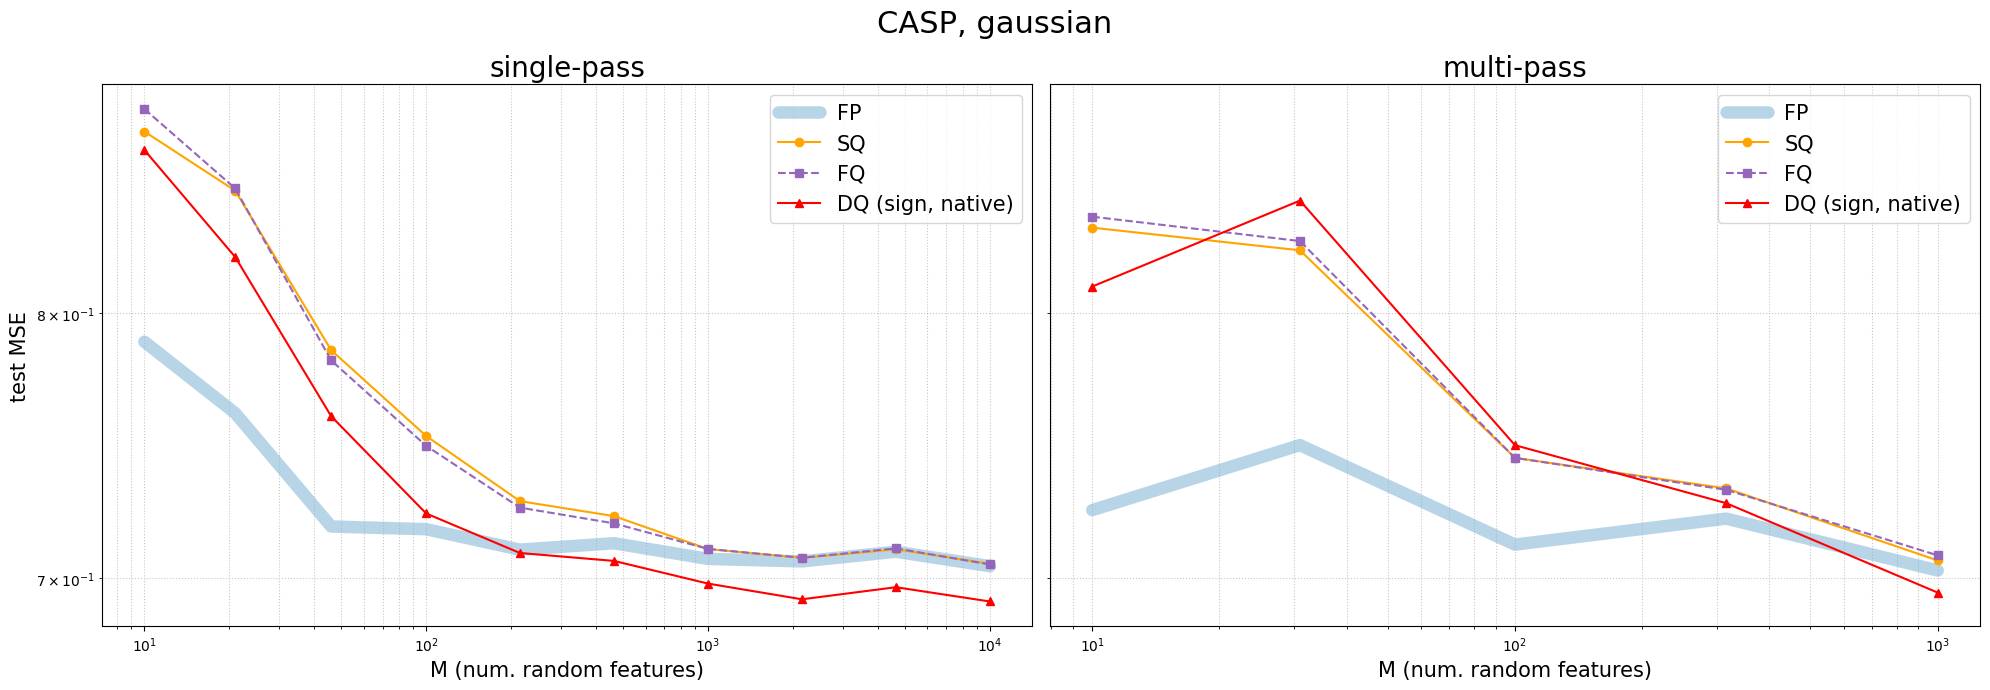

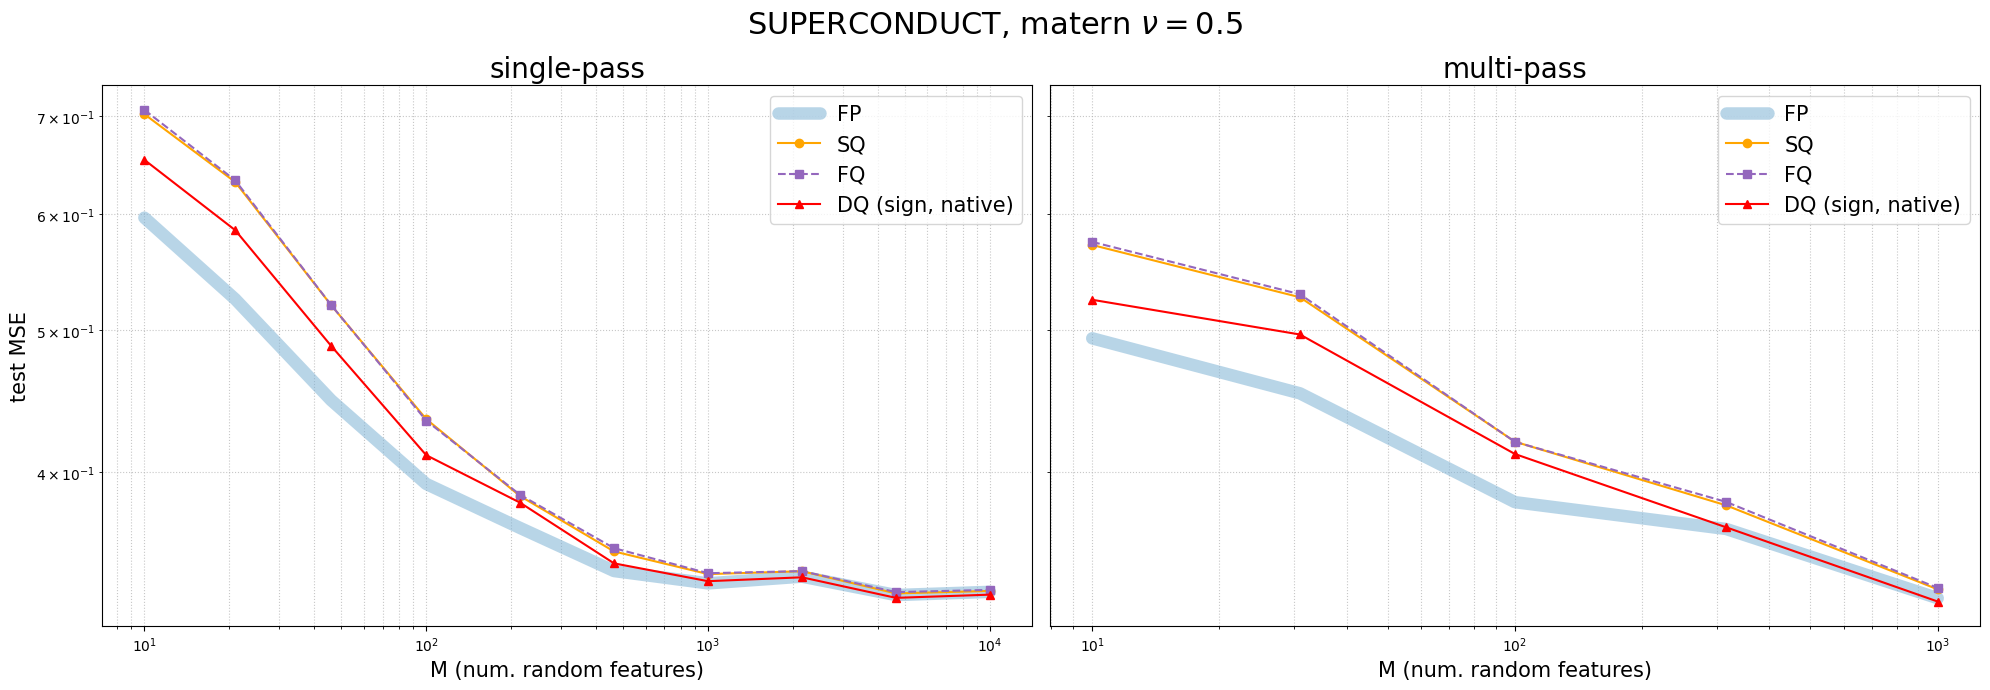

In [83]:
def plot_frozen(name_sp, name_mp, title, outfile):
    fig, axes = plt.subplots(1, 2, figsize=(20, 7), sharey=True)
    for ax, (nm, Mg, lab) in zip(axes, [(name_sp, _M, "single-pass"),
                                        (name_mp, _M_SHORT, "multi-pass")]):
        r = RES3[nm]
        ax.loglog(Mg, curve(r, "fp"), "-", color="#7fb3d5", lw=9, alpha=0.55,
                  solid_capstyle="round", label="FP")
        ax.loglog(Mg, curve(r, "quant_naive"),  "o-",  color="orange",  label="SQ")
        ax.loglog(Mg, curve(r, "frozen_naive"), "s--", color="#9467bd", label="FQ")
        ax.loglog(Mg, curve(r, "det"), "^-", color="red", label="DQ (sign, native)")
        ax.set_title(lab, fontsize=20)
        ax.set_xlabel("M (num. random features)", fontsize=15)
        ax.grid(True, which="both", ls=":", alpha=0.7)
        ax.legend(fontsize=15)
    axes[0].set_ylabel("test MSE", fontsize=15)
    fig.suptitle(title, fontsize=22)
    fig.tight_layout(); fig.savefig(outfile, dpi=150); print("saved", outfile)

plot_frozen("casp_gau_sp", "casp_gau_mp", "CASP, gaussian",
            "pics/casp_accVSM_singleVSmultiepoch.png")
plot_frozen("super_mat05_sp", "super_mat05_mp", r"SUPERCONDUCT, matern $\nu=0.5$",
            "pics/super_accVSM_singleVSmultiepoch.png")

for a, b in [("casp_gau_sp","casp_gau_mp"), ("super_mat05_sp","super_mat05_mp")]:
    for nm in (a, b):
        d = np.abs(curve(RES3[nm], "frozen_naive") - curve(RES3[nm], "quant_naive")).max()
        print(f"{nm}: max|SQ-FQ| = {d:.4f}")

saved pics/casp_accVSM_singleVSmultiepoch.png
saved pics/super_accVSM_singleVSmultiepoch.png
casp_gau_sp: max|SQ-FQ| = 0.0100
casp_gau_mp: max|SQ-FQ| = 0.0047
super_mat05_sp: max|SQ-FQ| = 0.0047
super_mat05_mp: max|SQ-FQ| = 0.0028


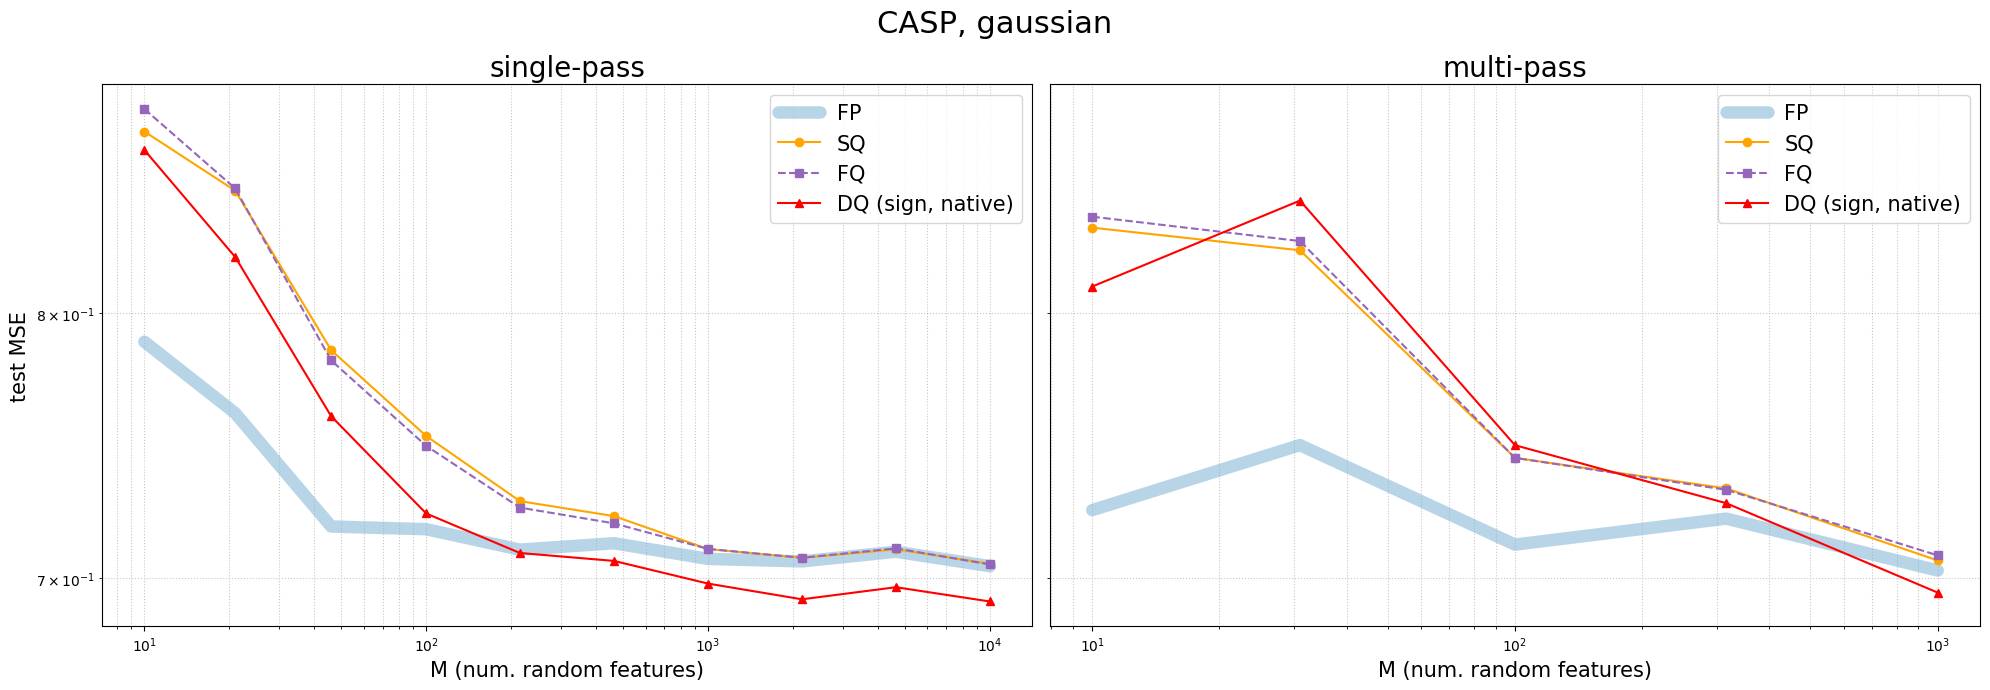

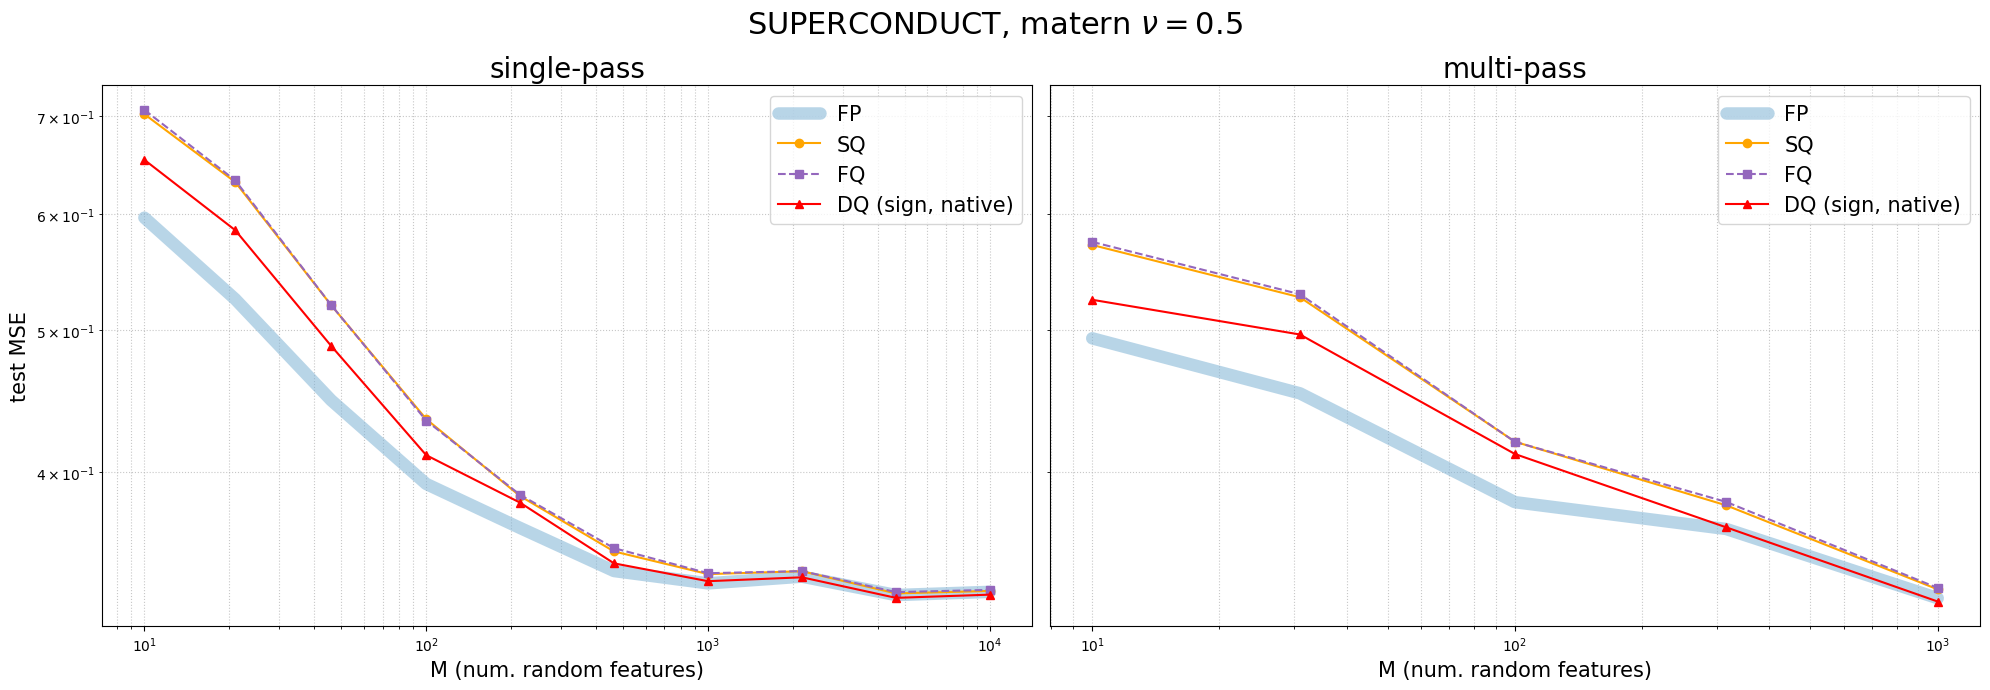

In [84]:
def plot_frozen(name_sp, name_mp, title, outfile):
    fig, axes = plt.subplots(1, 2, figsize=(20, 7), sharey=True)
    for ax, (nm, Mg, lab) in zip(axes, [(name_sp, _M, "single-pass"),
                                        (name_mp, _M_SHORT, "multi-pass")]):
        r = RES3[nm]
        ax.loglog(Mg, curve(r, "fp"), "-", color="#7fb3d5", lw=9, alpha=0.55,
                  solid_capstyle="round", label="FP")
        ax.loglog(Mg, curve(r, "quant_naive"),  "o-",  color="orange",  label="SQ")
        ax.loglog(Mg, curve(r, "frozen_naive"), "s--", color="#9467bd", label="FQ")
        ax.loglog(Mg, curve(r, "det"), "^-", color="red", label="DQ (sign, native)")
        ax.set_title(lab, fontsize=20)
        ax.set_xlabel("M (num. random features)", fontsize=15)
        ax.grid(True, which="both", ls=":", alpha=0.7)
        ax.legend(fontsize=15)
    axes[0].set_ylabel("test MSE", fontsize=15)
    fig.suptitle(title, fontsize=22)
    fig.tight_layout(); fig.savefig(outfile, dpi=150); print("saved", outfile)

plot_frozen("casp_gau_sp", "casp_gau_mp", "CASP, gaussian",
            "pics/casp_accVSM_singleVSmultiepoch.png")
plot_frozen("super_mat05_sp", "super_mat05_mp", r"SUPERCONDUCT, matern $\nu=0.5$",
            "pics/super_accVSM_singleVSmultiepoch.png")

for a, b in [("casp_gau_sp","casp_gau_mp"), ("super_mat05_sp","super_mat05_mp")]:
    for nm in (a, b):
        d = np.abs(curve(RES3[nm], "frozen_naive") - curve(RES3[nm], "quant_naive")).max()
        print(f"{nm}: max|SQ-FQ| = {d:.4f}")

saved pics/casp_accVSM_singleVSmultiepoch.png
saved pics/super_accVSM_singleVSmultiepoch.png
casp_gau_sp: max|SQ-FQ| = 0.0100
casp_gau_mp: max|SQ-FQ| = 0.0047
super_mat05_sp: max|SQ-FQ| = 0.0047
super_mat05_mp: max|SQ-FQ| = 0.0028


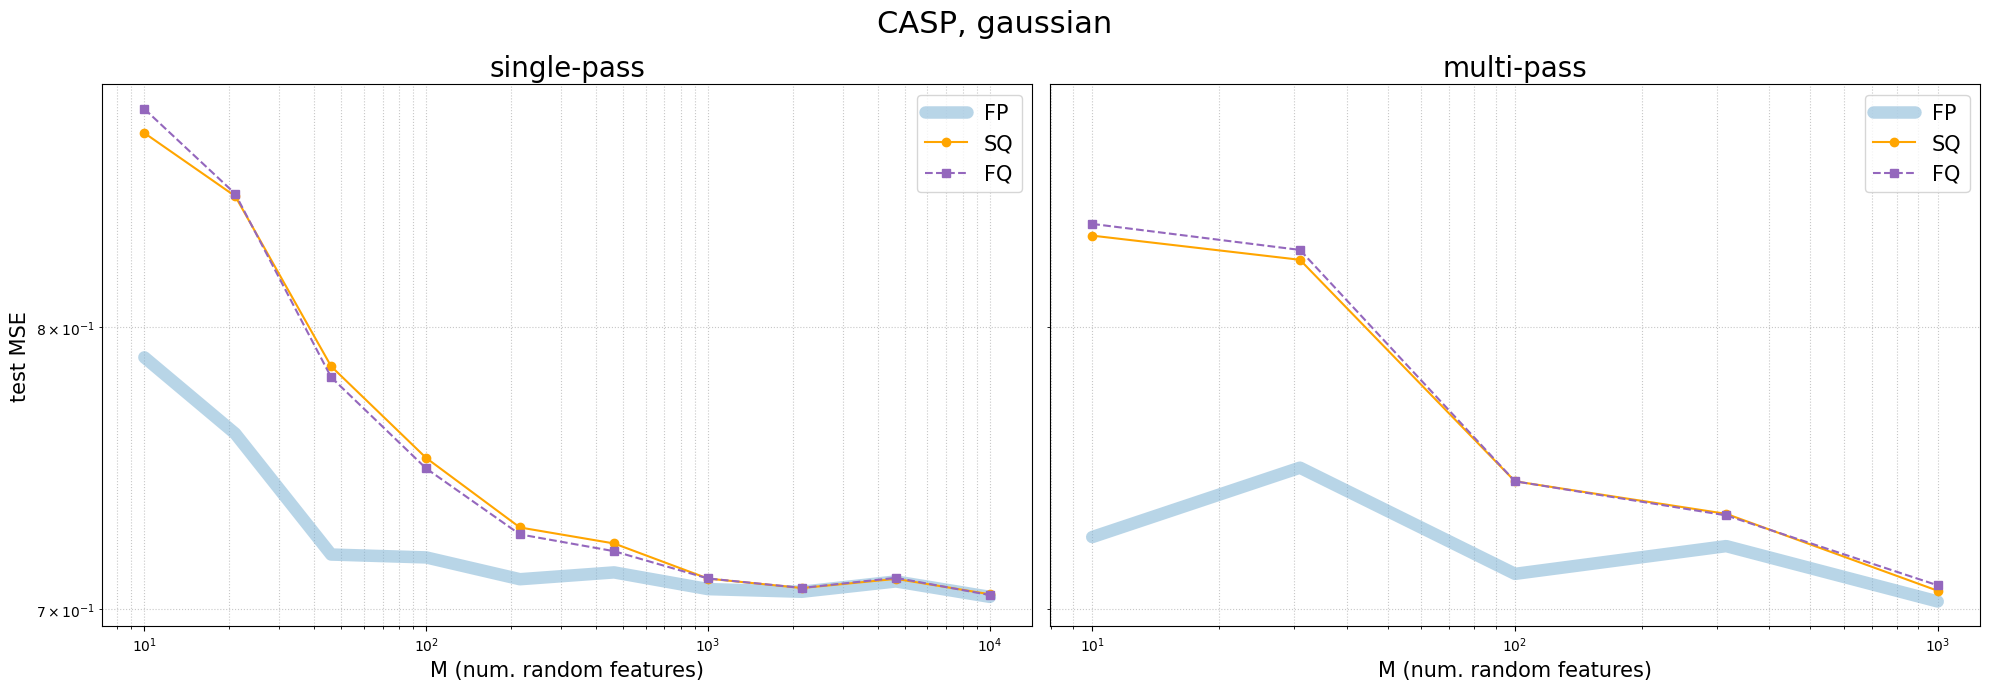

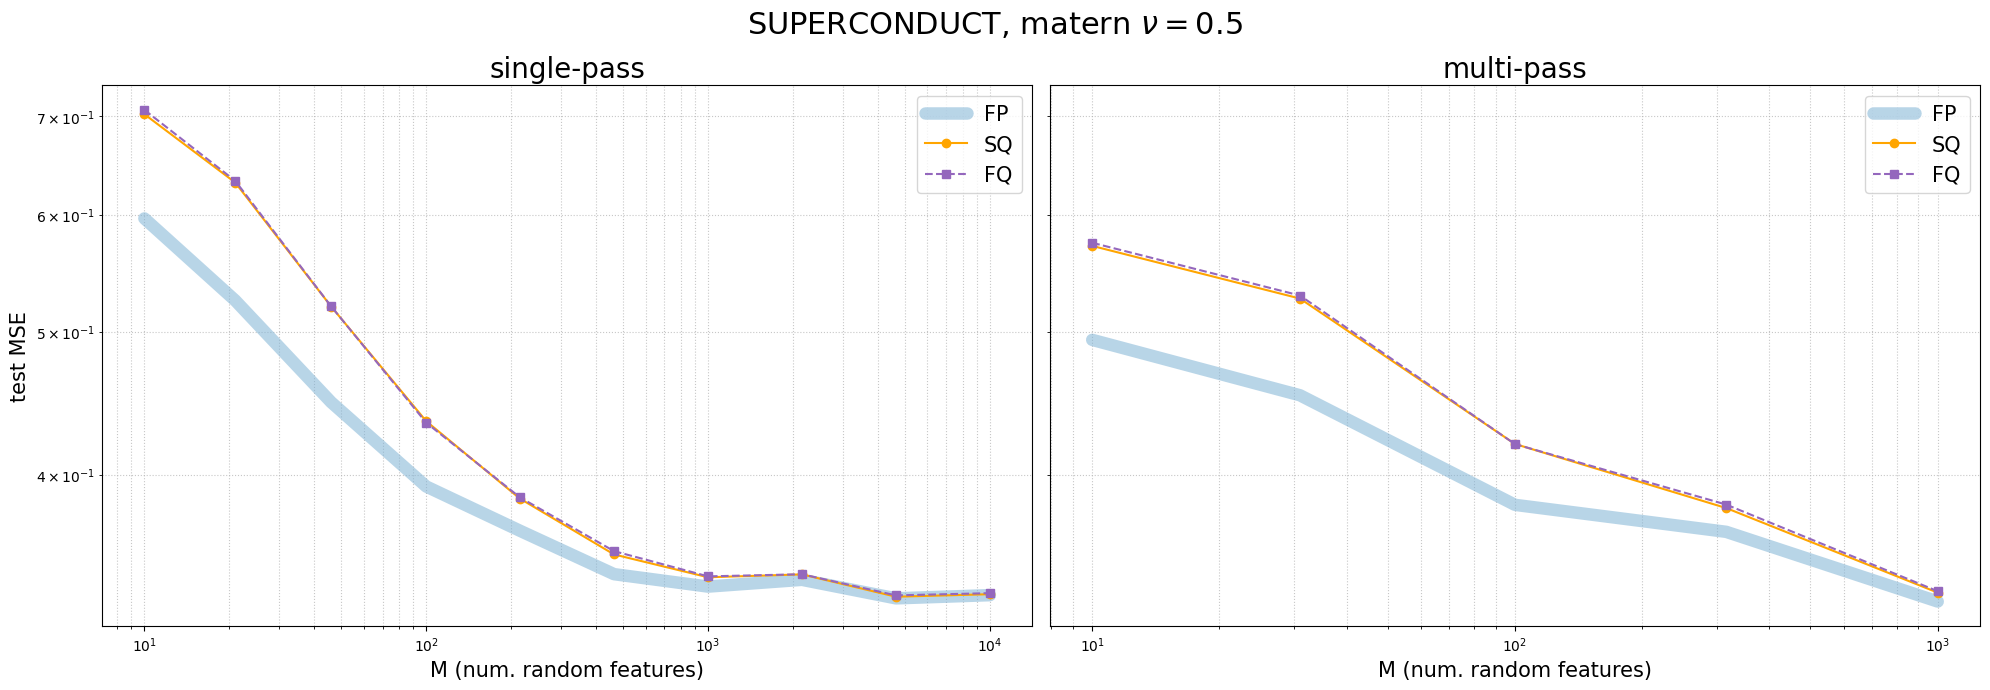

In [85]:
def plot_frozen(name_sp, name_mp, title, outfile):
    fig, axes = plt.subplots(1, 2, figsize=(20, 7), sharey=True)
    for ax, (nm, Mg, lab) in zip(axes, [(name_sp, _M, "single-pass"),
                                        (name_mp, _M_SHORT, "multi-pass")]):
        r = RES3[nm]
        ax.loglog(Mg, curve(r, "fp"), "-", color="#7fb3d5", lw=9, alpha=0.55,
                  solid_capstyle="round", label="FP")
        ax.loglog(Mg, curve(r, "quant_naive"),  "o-",  color="orange",  label="SQ")
        ax.loglog(Mg, curve(r, "frozen_naive"), "s--", color="#9467bd", label="FQ")
        ax.set_title(lab, fontsize=20)
        ax.set_xlabel("M (num. random features)", fontsize=15)
        ax.grid(True, which="both", ls=":", alpha=0.7)
        ax.legend(fontsize=15)
    axes[0].set_ylabel("test MSE", fontsize=15)
    fig.suptitle(title, fontsize=22)
    fig.tight_layout(); fig.savefig(outfile, dpi=150); print("saved", outfile)

plot_frozen("casp_gau_sp", "casp_gau_mp", "CASP, gaussian",
            "pics/casp_accVSM_singleVSmultiepoch.png")
plot_frozen("super_mat05_sp", "super_mat05_mp", r"SUPERCONDUCT, matern $\nu=0.5$",
            "pics/super_accVSM_singleVSmultiepoch.png")

for a, b in [("casp_gau_sp","casp_gau_mp"), ("super_mat05_sp","super_mat05_mp")]:
    for nm in (a, b):
        d = np.abs(curve(RES3[nm], "frozen_naive") - curve(RES3[nm], "quant_naive")).max()
        print(f"{nm}: max|SQ-FQ| = {d:.4f}")

In [94]:
%pip install numba

   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.8 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.8 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.8 MB 609.4 kB/s eta 0:00:04
   ------- -------------------------------- 0.5/2.8 MB 609.4 kB/s eta 0:00:04
   ----------- ---------------------------- 0.8/2.8 MB 623.6 kB/s eta 0:00:04
   ----------- ---------------------------- 0.8/2.8 MB 623.6 kB/s eta 0:00:04
   -------------- ------------------------- 1.0/2.8 MB 619.8 kB/s eta 0:00:03
   -------------- ------------------------- 1.0/2.8 MB 619.8 kB/s eta 0:00:03
   ------------------ --------------------- 1.3/2.8 MB 617.3 kB/s eta 0:00:03
   ------------------ --------------------- 1.3/2.8 MB 617.3 kB/s eta 0:00:03
   ---------------------- -----


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: C:\Users\2506b\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


  Using cached numba-0.67.0-cp314-cp314-win_amd64.whl.metadata (2.8 kB)
  Using cached llvmlite-0.49.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
Using cached numba-0.67.0-cp314-cp314-win_amd64.whl (2.8 MB)
   ---------------------------------------- 0.0/43.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/43.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/43.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/43.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/43.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/43.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/43.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/43.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/43.0 MB 391.3 kB/s eta 0:01:49
   ---------------------------------------- 0.5/43.0 MB 391.3 kB/s eta 0:01:49
   ---------------------------------------- 0.5/43.0 MB 391.3 kB/s eta 0:0


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: C:\Users\2506b\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [96]:
"""
fast_sgd.py -- accelerated run_comparison for bits=1 (numba).

Reproduces exactly the recursion of SGDPredictor.partial_fit:
    grad = (2/b) sum_i (<w,psi_i> - y_i) psi_i - 2 D w
    w <- w - lr_t grad,      lr_t = lr / (1 + decay t)
and the SamplingFeatureClass features with mode=1:
    fp      sqrt(2/M) cos(Om x + u)
    stoch   sqrt(2/M) (+-1),  P(+1) = (1 + cos)/2,  fresh dither at every step
    frozen  as stoch, with the dither drawn once
    det     sqrt(1/M) sign(cos)
"""
import gc, json
import numpy as np
from numba import njit

MODELS = ("fp", "quant_naive", "quant_scalar", "frozen_naive", "frozen_scalar", "det")

M_FP, M_STOCH, M_FROZEN, M_DET = 0, 1, 2, 3


@njit(cache=True, fastmath=True)
def _train(C, Sfz, y, idx, batch, lr, decay, D, mode, R, seed):
    np.random.seed(seed)
    M = C.shape[1]
    w = np.zeros(M)
    g = np.empty(M)
    psi = np.empty(M)
    T = idx.shape[0] // batch
    for t in range(T):
        for j in range(M):
            g[j] = 0.0
        for k in range(batch):
            i = idx[t * batch + k]
            pred = 0.0
            for j in range(M):
                if mode == M_FP:
                    v = R * C[i, j]
                elif mode == M_STOCH:
                    v = R if np.random.random() < 0.5 * (C[i, j] + 1.0) else -R
                elif mode == M_FROZEN:
                    v = R * Sfz[i, j]
                else:
                    v = R if C[i, j] >= 0.0 else -R
                psi[j] = v
                pred += v * w[j]
            res = pred - y[i]
            for j in range(M):
                g[j] += psi[j] * res
        lr_t = lr / (1.0 + decay * t)
        c = 2.0 * lr_t / batch
        d = 2.0 * lr_t * D
        for j in range(M):
            w[j] -= c * g[j] - d * w[j]
    return w


def _cos_matrix(sampler, X, chunk=4096):
    C = np.empty((X.shape[0], sampler.M), dtype=np.float32)
    for a in range(0, X.shape[0], chunk):
        C[a:a + chunk] = np.cos(X[a:a + chunk] @ sampler.w.T + sampler.u)
    return C


def _indices(n, cfg, rng):
    b = cfg["batch"]
    if cfg.get("single_pass", False):
        T = min(cfg["T"], n // b)
        return rng.permutation(n)[:T * b].astype(np.int64), T
    T = cfg["T"]
    return rng.integers(0, n, T * b).astype(np.int64), T


def sum_lr(cfg, n):
    T = min(cfg["T"], n // cfg["batch"]) if cfg.get("single_pass", False) else cfg["T"]
    return float((cfg["lr"] / (1.0 + cfg["decay"] * np.arange(T))).sum())


def Dbar_scalar(M, bits):
    return 1.0 / M if bits == 1 else (4.0 / 3.0) / (M * (2 ** bits - 1) ** 2)


def stored_bits(n_tr, n_te, M, bits, model):
    if model == "fp":
        return (n_tr + n_te) * M * 64
    if model in ("frozen_naive", "frozen_scalar"):
        return (n_tr + n_te) * M * bits
    if model == "det":
        return (n_tr + n_te) * M * 1
    return 0


def run_comparison_fast(Xtr, ytr, Xte, yte, sigma, M_values, cfg, n_reps=3, seed=42,
                        kernel="gaussian", nu=2.5, rho=None, dataset="dataset",
                        save_path=None, models=MODELS, **_ignored):
    from utils.sampling_and_features import SamplingFeatureClass

    if cfg["bits"] != 1:
        raise ValueError("fast path implemented for bits=1 only")

    n, d = Xtr.shape
    n_te = Xte.shape[0]
    rho = sigma if rho is None else rho
    ytr = np.ascontiguousarray(ytr, dtype=np.float64).ravel()
    yte = np.asarray(yte, dtype=np.float64).ravel()
    mean = {k: np.full(len(M_values), np.nan) for k in MODELS}
    std = {k: np.full(len(M_values), np.nan) for k in MODELS}

    for i, M in enumerate(M_values):
        M = int(M)
        Dsca = Dbar_scalar(M, cfg["bits"])
        Rq, Rdet = np.sqrt(2.0 / M), np.sqrt(1.0 / M)
        acc = {k: [] for k in MODELS}

        for r in range(n_reps):
            rs = seed + 1000 * r + i
            np.random.seed(rs)
            sampler = SamplingFeatureClass(M_RFF_dim=M, d_data_dim=d, sigma_ker=rho,
                                           choice=kernel, nu=nu, ro=rho)
            C = _cos_matrix(sampler, Xtr)
            Cte = _cos_matrix(sampler, Xte)
            gen = np.random.default_rng(rs + 1)
            Sfz = np.empty(C.shape, dtype=np.int8)
            for a in range(0, n, 4096):
                blk = C[a:a + 4096]
                Sfz[a:a + 4096] = np.where(gen.random(blk.shape) < 0.5 * (blk + 1.0), 1, -1)
            idx, _ = _indices(n, cfg, np.random.default_rng(rs))
            dummy = np.zeros((1, 1), dtype=np.int8)

            spec = [("fp", M_FP, Rq, 0.0), ("det", M_DET, Rdet, 0.0),
                    ("quant_naive", M_STOCH, Rq, 0.0), ("quant_scalar", M_STOCH, Rq, Dsca),
                    ("frozen_naive", M_FROZEN, Rq, 0.0), ("frozen_scalar", M_FROZEN, Rq, Dsca)]
            for name, mode, R, D in spec:
                if name not in models:
                    continue
                w = _train(C, Sfz if mode == M_FROZEN else dummy, ytr, idx, cfg["batch"],
                           cfg["lr"], cfg["decay"], D, mode, R, rs + 7)
                Rt = Rdet if name == "det" else Rq
                pred = (np.sign(Cte) * Rt if name == "det" else Cte * Rt) @ w
                acc[name].append(float(np.mean((pred - yte) ** 2)))

            del sampler, C, Cte, Sfz
            gc.collect()

        for k in models:
            v = np.asarray(acc[k], float)
            v[~np.isfinite(v)] = np.nan
            if not np.isnan(v).all():
                mean[k][i], std[k][i] = float(np.nanmean(v)), float(np.nanstd(v))
        print("  M={:>6}  ".format(M)
              + "  ".join("{}={:.4f}".format(k, mean[k][i]) for k in models))

    results = {
        "dataset": dataset, "kernel": kernel, "rho": float(rho),
        "nu": float(nu) if kernel == "matern" else None,
        "M_values": [int(m) for m in M_values], "d": int(d),
        "n_train": int(n), "n_test": int(n_te), "cfg": cfg, "n_reps": int(n_reps),
        "frozen_test": "fp", "sum_lr": sum_lr(cfg, n),
        "mean": {k: [float(v) for v in mean[k]] for k in MODELS},
        "std": {k: [float(v) for v in std[k]] for k in MODELS},
        "diagnostics": {},
        "stored_bits": {k: [stored_bits(n, n_te, int(m), cfg["bits"], k) for m in M_values]
                        for k in MODELS},
    }
    if save_path:
        json.dump(results, open(save_path, "w"), indent=1)
        print("[saved] " + save_path)
    return results

In [105]:
n_tr = 8000
_M_MP = _M
_MP = dict(T=int(n_tr*np.sqrt(n_tr)), batch=1, lr=1/n_tr/2, decay=0.0, bits=1)

CONFIGS_MP = {
    "casp_gau_mp":    dict(M_values=_M_MP, cfg=_MP, kernel="gaussian", dataset="casp"),
    "super_mat05_mp": dict(M_values=_M_MP, cfg=_MP, kernel="matern", nu=0.5,
                           dataset="superconduct"),
}

RES3 = globals().get("RES3", {})
for ds in ("casp", "superconduct"):
    X, y, sigma = load_dataset(ds, normalize=True, median_heuristic=True,
                               n_samples=10000, random_state=42)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
    for name, conf in CONFIGS_MP.items():
        if conf["dataset"] != ds:
            continue
        RES3[name] = run_comparison_fast(Xtr, ytr, Xte, yte, sigma, n_reps=3,
                                         save_path=f"v3_{name}.json", **conf)
        print(name, "done")

[load_dataset] 'casp' trovato in cache — caricamento da disco.
  [campionamento] Estratti 10000 / 45730 campioni.
  [normalizzazione] X e y standardizzati (media=0, std=1).

--- CASP ---
Physicochemical Properties of Protein Tertiary Structure (CASP)
  Campioni : 45730
  Feature  : 9  (F1-F9: attributi fisico-chimici dalla PDB)
  Target   : RMSD (Root Mean Square Deviation, in Angstrom)
  Fonte    : OpenML ID 42903
  Shape X  : (10000, 9)
  Shape y  : (10000,)  |  range y = [-1.266, 2.175]
  Sigma (mediana euristica distanze) : 3.016089

  M=    10  fp=0.7582  quant_naive=0.8619  quant_scalar=2.4549  frozen_naive=0.8639  frozen_scalar=2.3651  det=0.8416
  M=    21  fp=0.7569  quant_naive=0.8527  quant_scalar=0.7649  frozen_naive=0.8536  frozen_scalar=0.7719  det=0.8166
  M=    46  fp=0.7133  quant_naive=0.7663  quant_scalar=0.7140  frozen_naive=0.7673  frozen_scalar=0.7146  det=0.7496
  M=   100  fp=0.7169  quant_naive=0.7450  quant_scalar=0.7172  frozen_naive=0.7453  frozen_scalar=0.7

saved pics/casp_accVSM_singleVSmultiepoch.png
saved pics/super_accVSM_singleVSmultiepoch.png


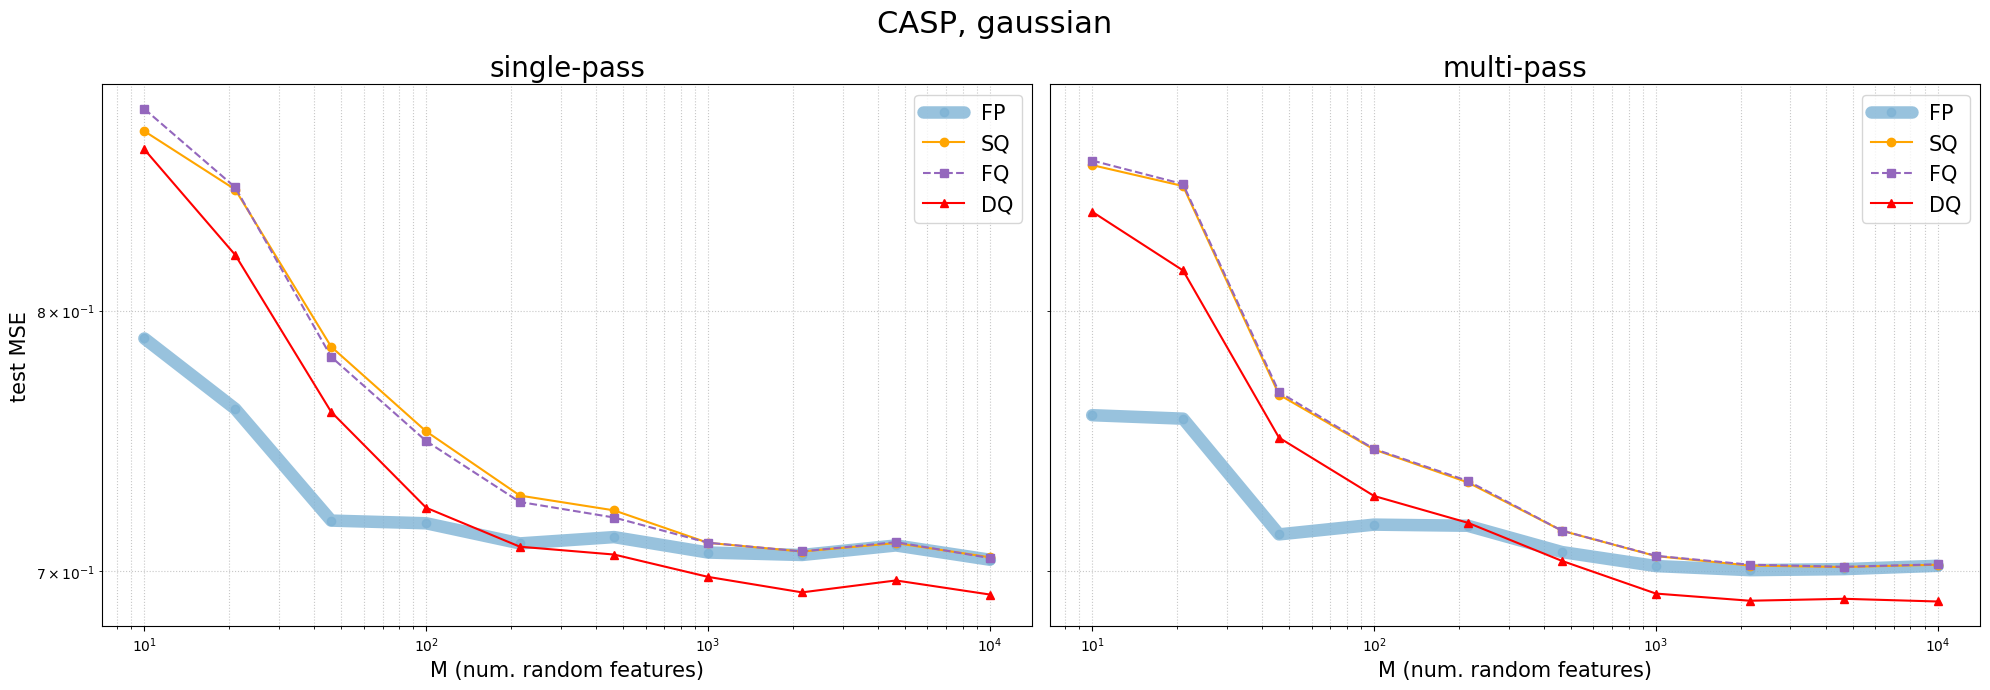

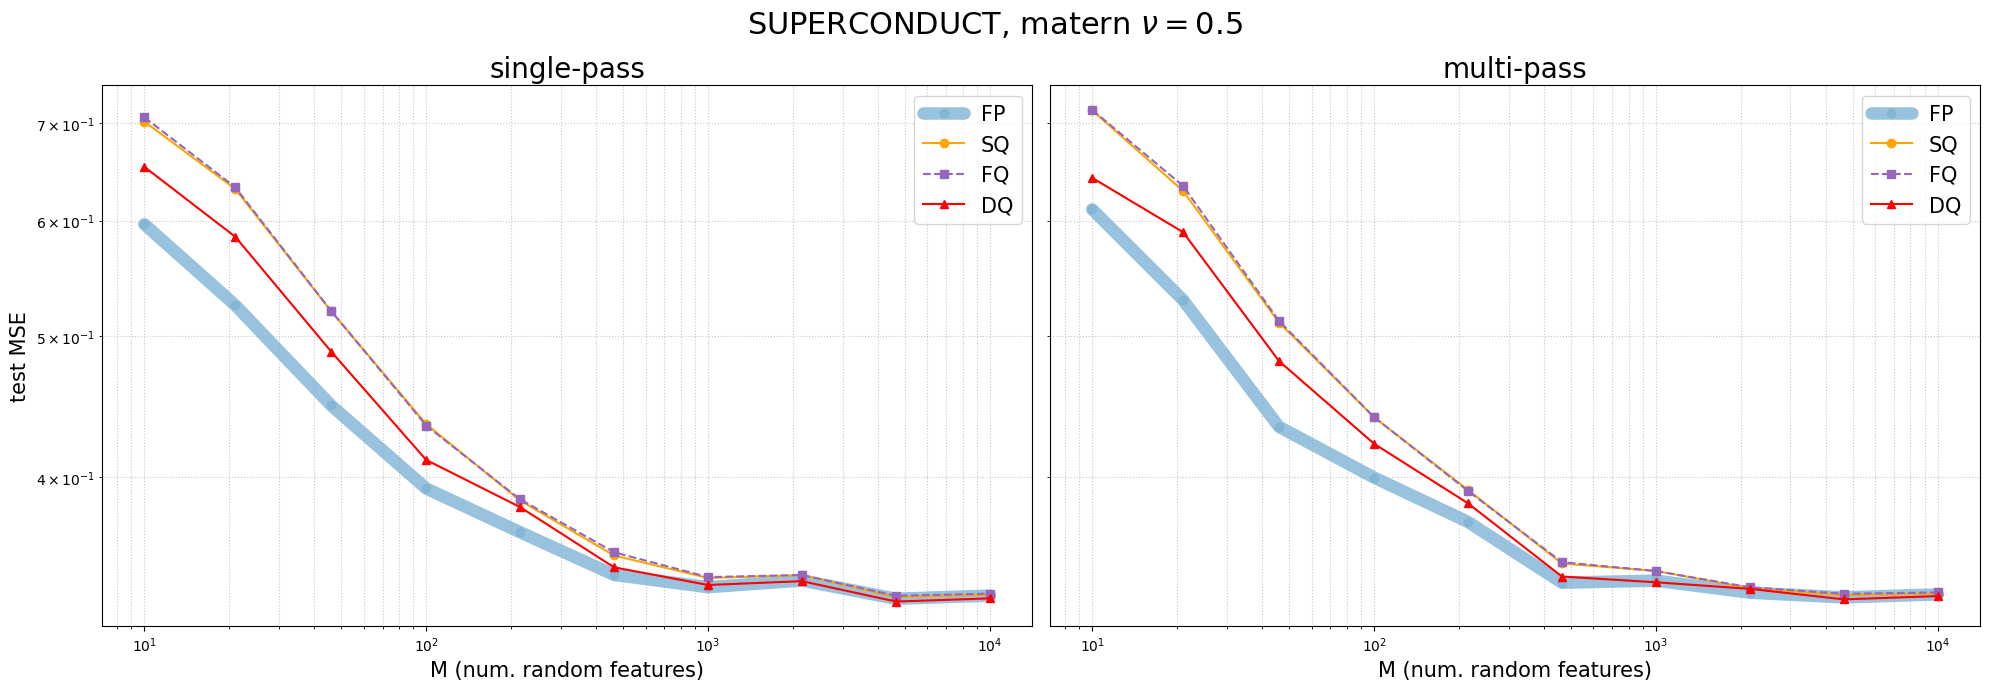

In [112]:
def plot_frozen_fast(name_sp, name_mp, title, outfile):
    fig, axes = plt.subplots(1, 2, figsize=(20, 7), sharey=True)
    for ax, (nm, lab) in zip(axes, [(name_sp, "single-pass"), (name_mp, "multi-pass")]):
        r = RES3[nm]
        Mg = np.asarray(r["M_values"])
        ax.loglog(Mg, curve(r, "fp"), "o-", color="#7fb3d5", lw=9, alpha=0.8,
                  solid_capstyle="round", label="FP")
        ax.loglog(Mg, curve(r, "quant_naive"),  "o-",  color="orange",  label="SQ")
        ax.loglog(Mg, curve(r, "frozen_naive"), "s--", color="#9467bd", label="FQ")
        ax.loglog(Mg, curve(r, "det"), "^-", color="red", label="DQ")
        ax.set_title(lab, fontsize=20)
        ax.set_xlabel("M (num. random features)", fontsize=15)
        ax.grid(True, which="both", ls=":", alpha=0.7)
        ax.legend(fontsize=15)
    axes[0].set_ylabel("test MSE", fontsize=15)
    fig.suptitle(title, fontsize=22)
    fig.tight_layout(); fig.savefig(outfile, dpi=150); print("saved", outfile)

plot_frozen_fast("casp_gau_sp", "casp_gau_mp", "CASP, gaussian",
                 "pics/casp_accVSM_singleVSmultiepoch.png")
plot_frozen_fast("super_mat05_sp", "super_mat05_mp", r"SUPERCONDUCT, matern $\nu=0.5$",
                 "pics/super_accVSM_singleVSmultiepoch.png")


In [113]:
for nm in ("casp_gau_sp", "casp_gau_mp", "super_mat05_sp", "super_mat05_mp"):
    print(nm, round(float(np.abs(curve(RES3[nm], "frozen_naive")
                                 - curve(RES3[nm], "quant_naive")).max()), 4))
                                 

casp_gau_sp 0.01
casp_gau_mp 0.002
super_mat05_sp 0.0047
super_mat05_mp 0.005


In [114]:
for nm in ("casp_gau_sp", "casp_gau_mp", "super_mat05_sp", "super_mat05_mp"):
    Mg = np.asarray(RES3[nm]["M_values"])
    d = np.abs(curve(RES3[nm], "frozen_naive") - curve(RES3[nm], "quant_naive"))
    print(nm, round(float(d[Mg >= 100].max()), 4))

casp_gau_sp 0.0037
casp_gau_mp 0.0006
super_mat05_sp 0.0018
super_mat05_mp 0.0008


In [115]:
import json; print(json.load(open("v3_casp_gau_sp.json"))["cfg"])

{'T': 8000, 'batch': 1, 'lr': 0.005590169943749474, 'decay': 0.0, 'bits': 1}


In [116]:
n_tr = 8000
_M  = np.logspace(1, 4, 10, dtype=int)
_SP      = dict(T=n_tr, batch=1, lr=1/np.sqrt(n_tr)/2, decay=0.0, bits=1)
_SP_PERM = dict(_SP, single_pass=True)

KER = [("gau", dict(kernel="gaussian")),
       ("mat05", dict(kernel="matern", nu=0.5)),
       ("mat15", dict(kernel="matern", nu=1.5))]

# FQ without replacement: only frozen_naive and fp are needed (fp as a control)
for ds in ("casp", "superconduct"):
    tag = "casp" if ds == "casp" else "super"
    X, y, sigma = load_dataset(ds, normalize=True, median_heuristic=True,
                               n_samples=10000, random_state=42)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
    for kn, kw in KER:
        name = f"{tag}_{kn}_perm"
        RES3[name] = run_comparison_fast(Xtr, ytr, Xte, yte, sigma, M_values=_M,
                                         cfg=_SP_PERM, n_reps=3, dataset=ds,
                                         models=("fp", "frozen_naive"),
                                         save_path=f"v3_{name}.json", **kw)
        print(name, "done")

[load_dataset] 'casp' trovato in cache — caricamento da disco.
  [campionamento] Estratti 10000 / 45730 campioni.
  [normalizzazione] X e y standardizzati (media=0, std=1).

--- CASP ---
Physicochemical Properties of Protein Tertiary Structure (CASP)
  Campioni : 45730
  Feature  : 9  (F1-F9: attributi fisico-chimici dalla PDB)
  Target   : RMSD (Root Mean Square Deviation, in Angstrom)
  Fonte    : OpenML ID 42903
  Shape X  : (10000, 9)
  Shape y  : (10000,)  |  range y = [-1.266, 2.175]
  Sigma (mediana euristica distanze) : 3.016089

  M=    10  fp=0.7640  frozen_naive=0.8806
  M=    21  fp=0.7605  frozen_naive=0.8556
  M=    46  fp=0.7143  frozen_naive=0.7678
  M=   100  fp=0.7170  frozen_naive=0.7440
  M=   215  fp=0.7187  frozen_naive=0.7350
  M=   464  fp=0.7109  frozen_naive=0.7186
  M=  1000  fp=0.7041  frozen_naive=0.7081
  M=  2154  fp=0.7041  frozen_naive=0.7060
  M=  4641  fp=0.7019  frozen_naive=0.7023
  M= 10000  fp=0.7075  frozen_naive=0.7076
[saved] v3_casp_gau_perm.j

In [117]:
def merged(tag, kn):
    rep, per = RES3[f"{tag}_{kn}_sp"], RES3[f"{tag}_{kn}_perm"]
    out = json.loads(json.dumps(rep))
    out["mean"]["frozen_naive"] = per["mean"]["frozen_naive"]
    out["std"]["frozen_naive"]  = per["std"]["frozen_naive"]
    out["mean"]["fp_perm"]      = per["mean"]["fp"]
    return out

for tag in ("casp", "super"):
    for kn, _ in KER:
        RES3[f"{tag}_{kn}_mix"] = merged(tag, kn)

In [118]:
for tag in ("casp", "super"):
    for kn, _ in KER:
        r = RES3[f"{tag}_{kn}_mix"]
        d = np.abs(np.array(r["mean"]["fp"]) - np.array(r["mean"]["fp_perm"]))
        g = np.abs(np.array(r["mean"]["frozen_naive"]) - np.array(r["mean"]["quant_naive"]))
        print(f"{tag}_{kn}: max|FP-FPperm|={d.max():.4f}  max|SQ-FQ|={g.max():.4f}")

casp_gau: max|FP-FPperm|=0.0247  max|SQ-FQ|=0.0175
casp_mat05: max|FP-FPperm|=0.0141  max|SQ-FQ|=0.0166
casp_mat15: max|FP-FPperm|=0.0146  max|SQ-FQ|=0.0072
super_gau: max|FP-FPperm|=0.0331  max|SQ-FQ|=0.0193
super_mat05: max|FP-FPperm|=0.0205  max|SQ-FQ|=0.0116
super_mat15: max|FP-FPperm|=0.0161  max|SQ-FQ|=0.0287


saved pics/rerun_casp_matVSmatVSgaus.png
saved pics/rerun_super_matVSmatVSgaus.png


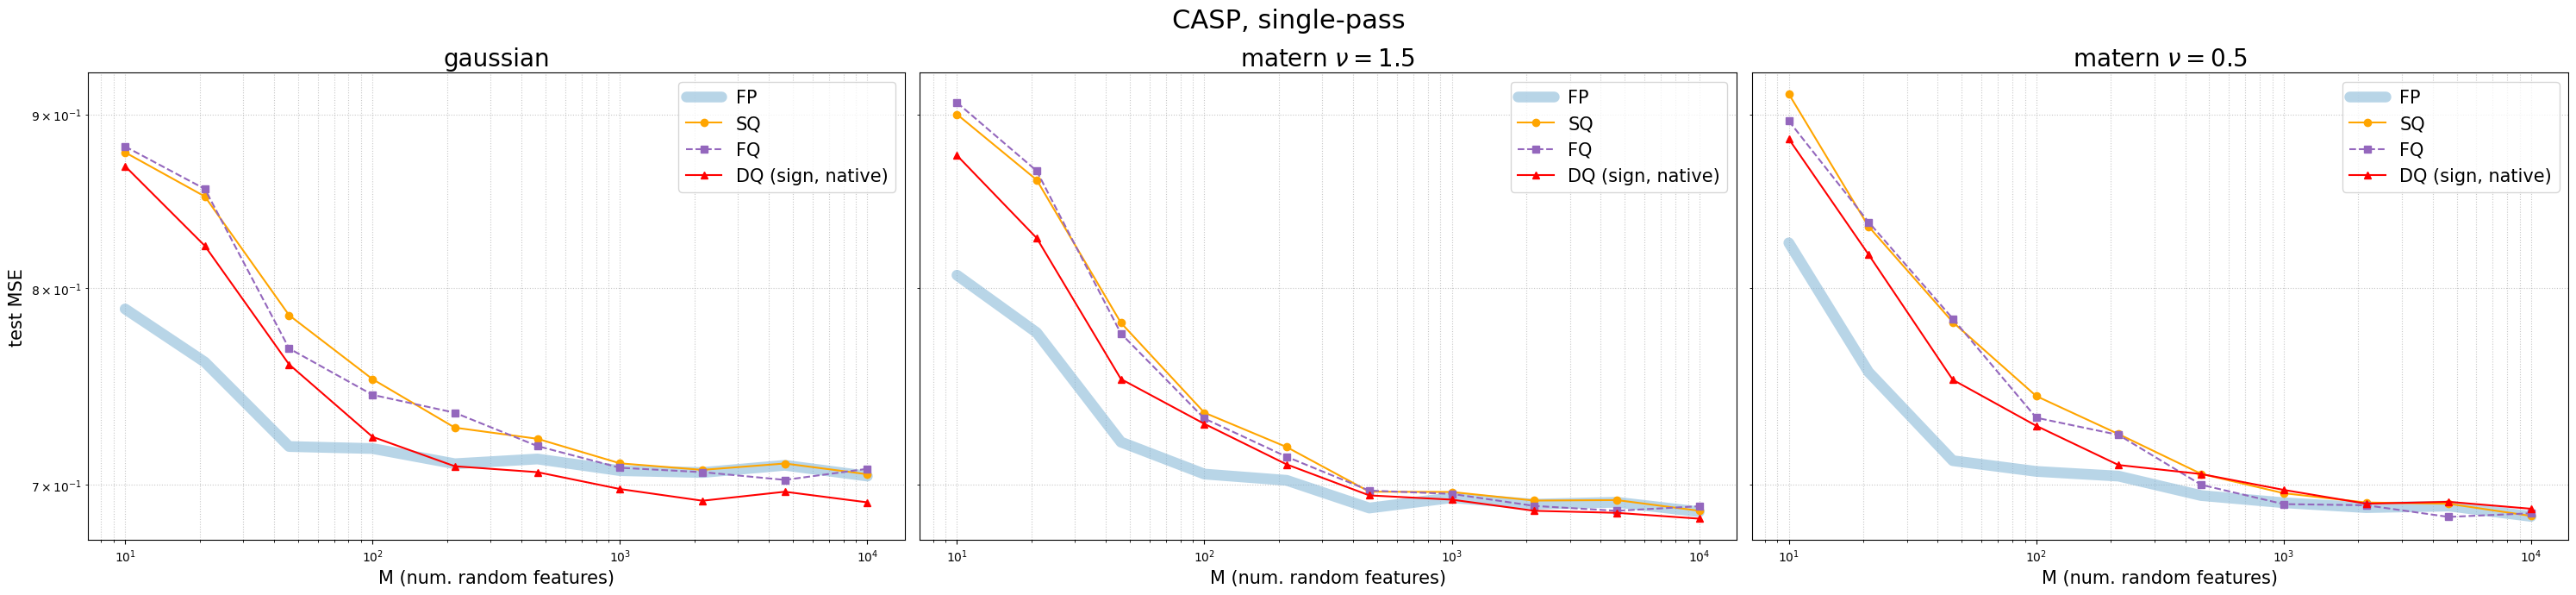

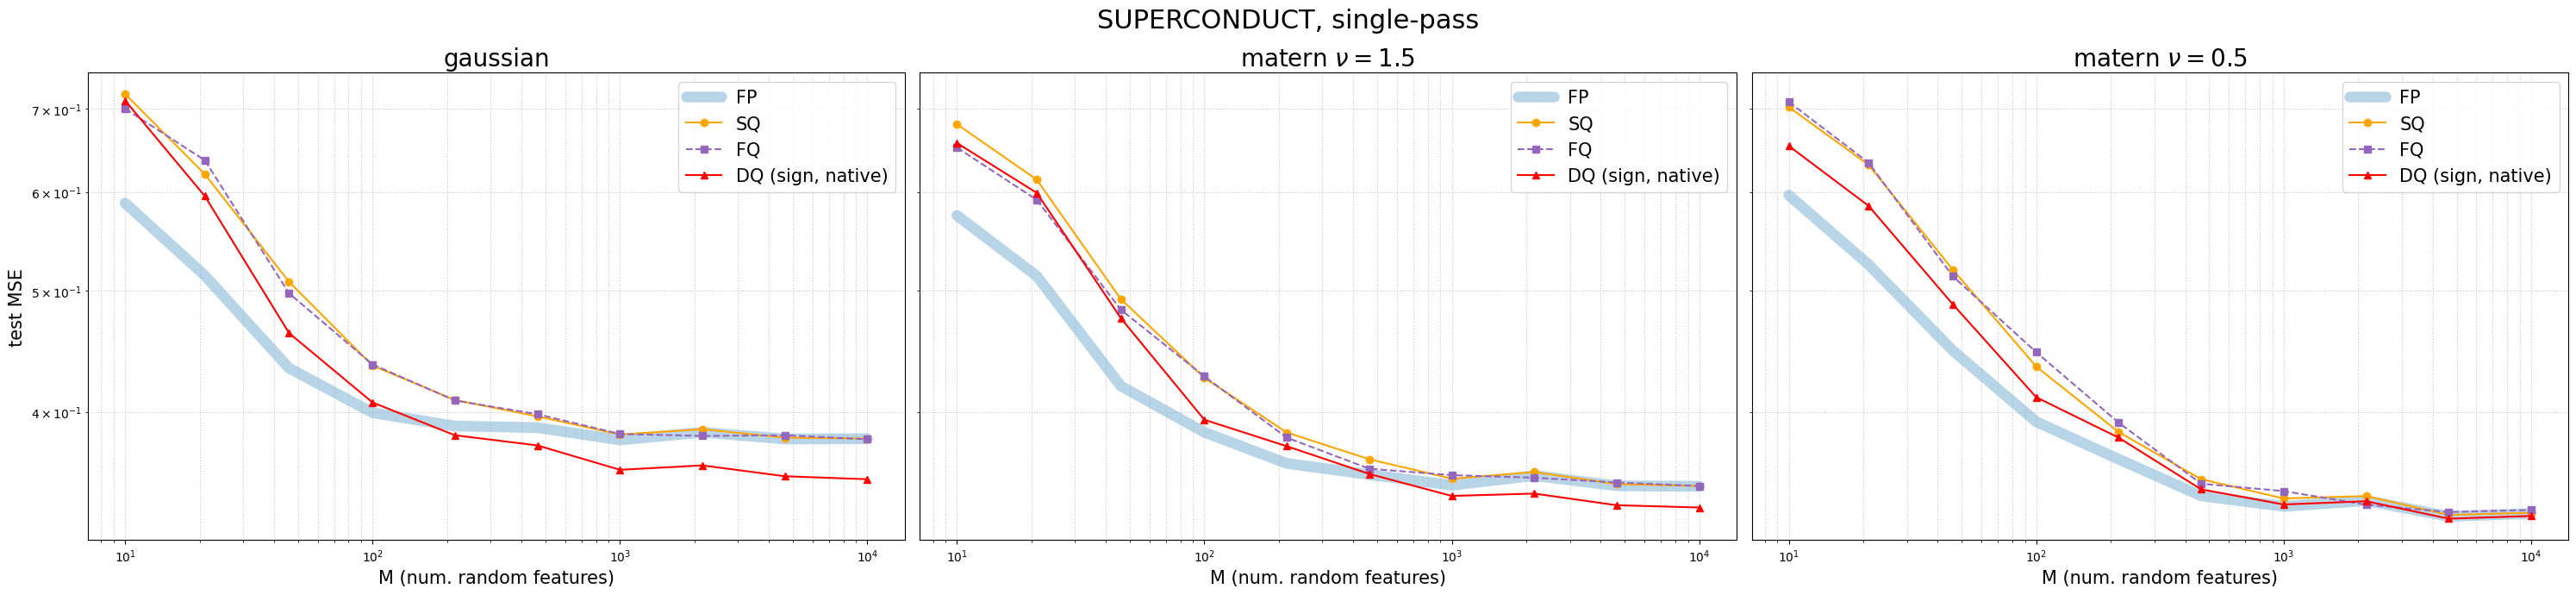

In [119]:
def plot_kernels(tag, title, outfile):
    fig, axes = plt.subplots(1, 3, figsize=(30, 7), sharey=True)
    lbl = [("gau", "gaussian"), ("mat15", r"matern $\nu=1.5$"), ("mat05", r"matern $\nu=0.5$")]
    for ax, (kn, lab) in zip(axes, lbl):
        r = RES3[f"{tag}_{kn}_mix"]; Mg = np.asarray(r["M_values"])
        ax.loglog(Mg, curve(r, "fp"), "-", color="#7fb3d5", lw=9, alpha=0.55,
                  solid_capstyle="round", label="FP")
        ax.loglog(Mg, curve(r, "quant_naive"),  "o-",  color="orange",  label="SQ")
        ax.loglog(Mg, curve(r, "frozen_naive"), "s--", color="#9467bd", label="FQ")
        ax.loglog(Mg, curve(r, "det"), "^-", color="red", label="DQ (sign, native)")
        ax.set_title(lab, fontsize=20); ax.set_xlabel("M (num. random features)", fontsize=15)
        ax.grid(True, which="both", ls=":", alpha=0.7); ax.legend(fontsize=15)
    axes[0].set_ylabel("test MSE", fontsize=15)
    fig.suptitle(title, fontsize=22); fig.tight_layout()
    fig.savefig(outfile, dpi=150); print("saved", outfile)

plot_kernels("casp",  "CASP, single-pass",         "pics/rerun_casp_matVSmatVSgaus.png")
plot_kernels("super", "SUPERCONDUCT, single-pass", "pics/rerun_super_matVSmatVSgaus.png")

saved pics/rerun_casp_accVSM_singleVSmultiepoch.png
saved pics/rerun_super_accVSM_singleVSmultiepoch.png


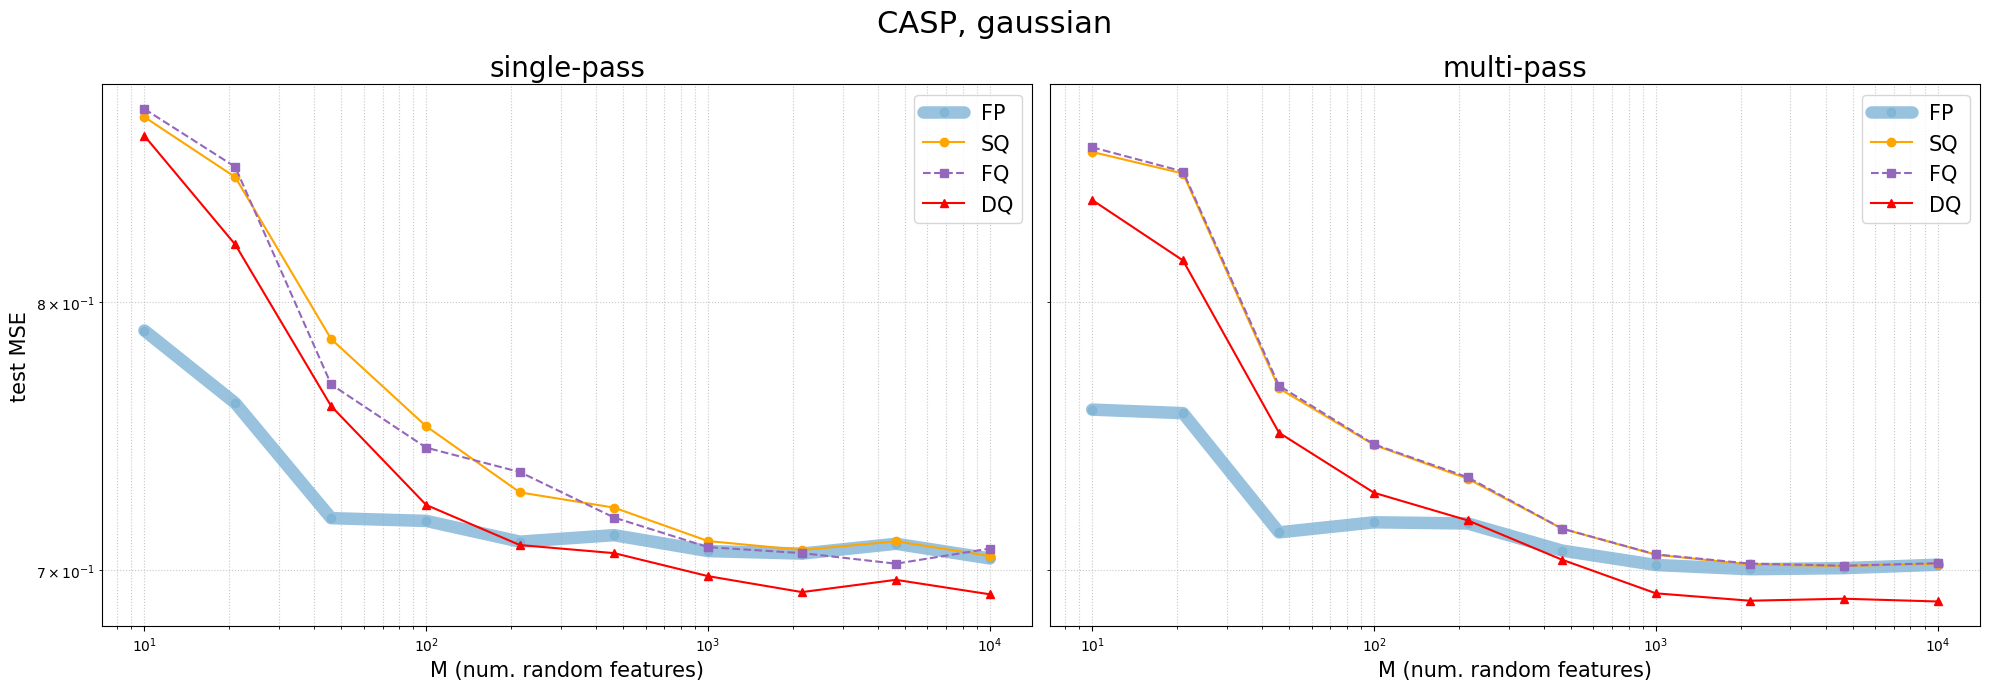

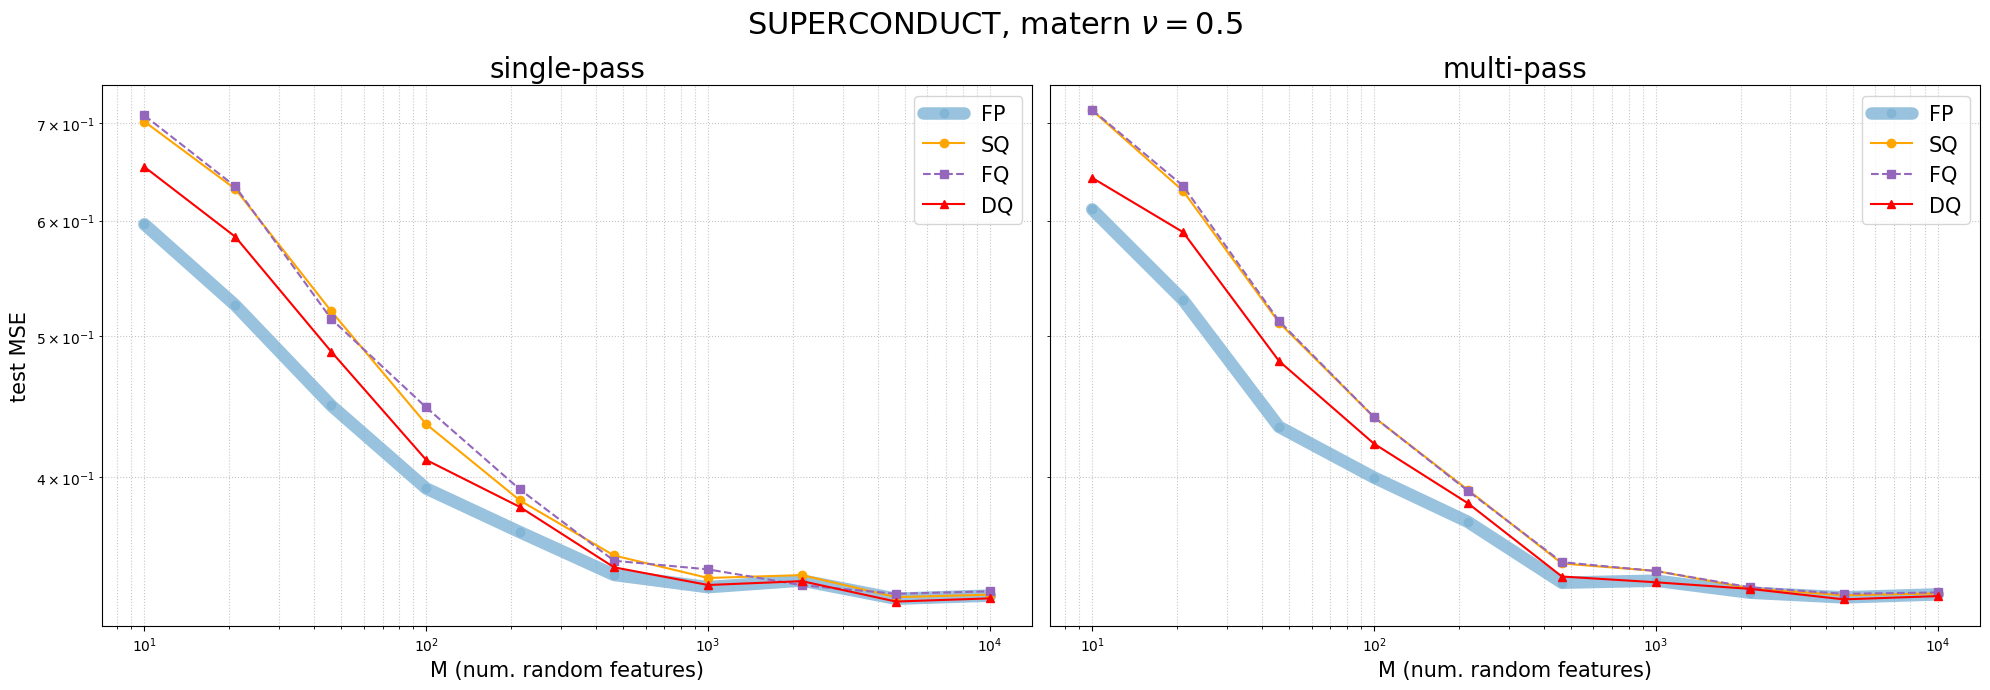

In [120]:
plot_frozen_fast("casp_gau_mix", "casp_gau_mp", "CASP, gaussian",
                 "pics/rerun_casp_accVSM_singleVSmultiepoch.png")
plot_frozen_fast("super_mat05_mix", "super_mat05_mp", r"SUPERCONDUCT, matern $\nu=0.5$",
                 "pics/rerun_super_accVSM_singleVSmultiepoch.png")

In [121]:
for tag in ("casp", "super"):
    for kn, _ in KER:
        r = RES3[f"{tag}_{kn}_mix"]
        dfp = np.abs(np.array(r["mean"]["fp"]) - np.array(r["mean"]["fp_perm"]))
        gap = np.abs(curve(r, "frozen_naive") - curve(r, "quant_naive"))
        exc = np.abs((curve(r, "frozen_naive") - np.array(r["mean"]["fp_perm"]))
                     - (curve(r, "quant_naive") - np.array(r["mean"]["fp"])))
        print(f"{tag}_{kn}:  |FP-FPperm|={dfp.max():.4f}  |SQ-FQ|={gap.max():.4f}  "
              f"|excess diff|={exc.max():.4f}")

casp_gau:  |FP-FPperm|=0.0247  |SQ-FQ|=0.0175  |excess diff|=0.0282
casp_mat05:  |FP-FPperm|=0.0141  |SQ-FQ|=0.0166  |excess diff|=0.0046
casp_mat15:  |FP-FPperm|=0.0146  |SQ-FQ|=0.0072  |excess diff|=0.0080
super_gau:  |FP-FPperm|=0.0331  |SQ-FQ|=0.0193  |excess diff|=0.0138
super_mat05:  |FP-FPperm|=0.0205  |SQ-FQ|=0.0116  |excess diff|=0.0137
super_mat15:  |FP-FPperm|=0.0161  |SQ-FQ|=0.0287  |excess diff|=0.0343
